# **第二組期末專案：對 PTT「科技執法」相關文章進行文本分析**

**課程：** 社群媒體分析  

**教授：** 黃三益 老師

**組員：** 陳彥廷 N134020005、陳葳 N134320010、鍾宛樺 N134320013、翁瑞琳 N134320022

---

## **專案背景與說明**

近年來，政府為提升交通安全與執法效率，陸續導入科技執法設備，例如區間測速、違規停車偵測、闖紅燈照相、未依規定禮讓行人等自動化執法方式。這類政策雖然以改善交通秩序為目標，但在民眾討論中也經常引發正反意見，例如執法是否合理、是否以開罰為目的、設備設置地點是否適當，以及對用路人行為的影響。

PTT 作為台灣重要的網路討論平台，累積了大量民眾對科技執法的即時反應與意見，因此本專案希望透過文本分析方法，觀察網友對科技執法議題的討論重點與情緒傾向。
### **專案目的**
本專案以 PTT 中與「科技執法」相關的文章作為分析資料，透過中文斷詞、詞頻分析、情緒分析與主題觀察，了解網友對科技執法的主要討論內容。

具體而言，本研究希望達成以下目標：

1. 分析 PTT 科技執法相關文章中常出現的關鍵詞。
2. 觀察不同看板中對科技執法議題的討論差異。
3. 探討網友對科技執法的主要態度與情緒傾向。
4. 歸納科技執法相關討論中的常見爭議，例如交通安全、罰單、測速、用路人權益與政府政策信任等議題。

---

## **報告大綱**

### **資料概況**
- **資料來源**：透過 TarFlow 蒐集 PTT 中與「科技執法」相關之文章。
- **分析主題**：PTT「科技執法」相關文章之文本分析
- **關鍵字**：科技執法
- **時間範圍**：2018-01-08 ～ 2026-05-02
- **原始資料量**：共 1,433 篇文章
- **資料來源平台**：PTT
- **涵蓋看板**：car、biker、Hsinchu、Kaohsiung、TaichungBun、Tainan

# 1. 前置作業

## 1.套件載入

In [ ]:
#本次所需檔案執行後將自動上傳
import gdown

files = {
    "car.csv": "17QVx5g5UMDHhCgwSfltUP9NDkefiUDT8",
    "dict.txt": "1erLfrjQD0kbaOEFzzh8PriX-vO-Wuhnw",
    "stopwords.txt": "1QWyrNw_kWJOVa3TRHIzclYw0vYsKXsNE",
    "LIWC_CH.xlsx": "1sjUd8FZgBDhBPmmDYPSSGggMkqm12MC-",
    "user_dict.txt": "1vmC2RxIa4TG8MGU6o8IBHWEjdwxnWWwY",
    "sentence_table_buffet.csv": "1_VviAMl_F524dvXA9ZLVDPs5dInUdhE5",
    "entity_table_buffet.csv": "1hEJnzf-3FE3Mb11RXRuG4ae-g8l5GJJP",
    "pos_table_buffet.csv": "1B2kerBOy9ujW0_kHnhfW62rrNXUGISKS"
}

for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading {filename}...")
    gdown.download(url, filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=17QVx5g5UMDHhCgwSfltUP9NDkefiUDT8
To: /content/car.csv
100%|██████████| 16.8M/16.8M [00:00<00:00, 36.6MB/s]


Downloading...
From: https://drive.google.com/uc?id=1erLfrjQD0kbaOEFzzh8PriX-vO-Wuhnw
To: /content/dict.txt
100%|██████████| 4.15M/4.15M [00:00<00:00, 27.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1QWyrNw_kWJOVa3TRHIzclYw0vYsKXsNE
To: /content/stopwords.txt
100%|██████████| 22.6k/22.6k [00:00<00:00, 42.5MB/s]


Downloading...
From: https://drive.google.com/uc?id=1sjUd8FZgBDhBPmmDYPSSGggMkqm12MC-
To: /content/LIWC_CH.xlsx
100%|██████████| 77.8k/77.8k [00:00<00:00, 3.76MB/s]


Downloading...
From: https://drive.google.com/uc?id=1vmC2RxIa4TG8MGU6o8IBHWEjdwxnWWwY
To: /content/user_dict.txt
100%|██████████| 929/929 [00:00<00:00, 3.71MB/s]


Downloading...
From: https://drive.google.com/uc?id=1_VviAMl_F524dvXA9ZLVDPs5dInUdhE5
To: /content/sentence_table_buffet.csv
100%|██████████| 2.32M/2.32M [00:00<00:00, 17.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1hEJnzf-3FE3Mb11RXRuG4ae-g8l5GJJP
To: /content/entity_table_buffet.csv
100%|██████████| 463k/463k [00:00<00:00, 6.19MB/s]


Downloading...
From: https://drive.google.com/uc?id=1B2kerBOy9ujW0_kHnhfW62rrNXUGISKS
To: /content/pos_table_buffet.csv
100%|██████████| 5.97M/5.97M [00:00<00:00, 39.5MB/s]


In [ ]:
import os
import re
import time
import datetime
from functools import reduce
from collections import Counter
from pprint import pprint

import jieba.analyse
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap

In [ ]:
!apt-get -qq install fonts-noto-cjk

In [ ]:
import os

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
print(os.path.exists(font_path))

True


In [ ]:
# 統一繪圖藍色=正面、橘色=負面
colors = ["#1f77b4", "#ff7f0e"]

## 1.2 資料匯入

In [ ]:
df = pd.read_csv("car.csv")
df["artDate"] = pd.to_datetime(df["artDate"])
df['artDate'] = df['artDate'].dt.date
df.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,cute320518,biker,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Tudo11927"", ...",117.19.182.204,2018-06-10 14:01:38,ptt
1,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,strellson,biker,https://tw.news.appledaily.com/life/realtime/2...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""SSSONIC"", ""c...",101.136.200.246,2018-10-08 02:30:52,ptt
2,3,https://www.ptt.cc/bbs/biker/M.1538495370.A.4F...,Re:[新車]GSX-R150,2018-10-02,elynn889,biker,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。\n你的定位是平日通勤、假日跑山，那你的...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""tsukie2887"",...",114.35.25.145,2018-10-08 02:31:06,ptt
3,4,https://www.ptt.cc/bbs/biker/M.1549095106.A.5E...,[閒聊]男大生騎白牌硬闖高架自摔倒地險遭輾頭,2019-02-02,wwf1588,biker,原文網址\nhttps://news.ebc.net.tw/News/Article/149...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""LieFang"", ""c...",101.136.29.178,2019-12-14 14:59:08,ptt
4,5,https://www.ptt.cc/bbs/biker/M.1553663126.A.79...,[新聞]防範南迴舊台9線成另條北宜公路區間速率,2019-03-27,Naraka,biker,新聞來源 自由時報\nhttps://news.ltn.com.tw/news/life/b...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""HsihHan"", ""c...",163.24.141.208,2019-12-14 15:04:01,ptt


# 2. 文本預處理 (Text Preprocessing)

## 2.1 資料清洗 (Data Cleaning)

In [ ]:
clear_df = df.copy()

#去除本次不會用到的欄位
drop_cols = ['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource']
clear_df.drop(drop_cols, axis = 1, inplace = True)

#去除文章內容為空值的筆數
clear_df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

#新增['sentence']欄位，用'。'取代'\n\n'，並移除'\n'
clear_df['sentence'] = clear_df['artContent'].str.replace(r'\n\n','。', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n','', regex=True)

#移除內文中的網址
clear_df['sentence'] = clear_df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df.head()

,system_id,artUrl,artTitle,artDate,artContent,sentence
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...
1,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,保持安全車距觀念仍不足。107/09/27。550CC以上紅牌大型重機爭取上國道各界爭議，...
2,3,https://www.ptt.cc/bbs/biker/M.1538495370.A.4F...,Re:[新車]GSX-R150,2018-10-02,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。\n你的定位是平日通勤、假日跑山，那你的...,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。你的定位是平日通勤、假日跑山，那你的通勤...
3,4,https://www.ptt.cc/bbs/biker/M.1549095106.A.5E...,[閒聊]男大生騎白牌硬闖高架自摔倒地險遭輾頭,2019-02-02,原文網址\nhttps://news.ebc.net.tw/News/Article/149...,原文網址 要我上去 真的不太想。
4,5,https://www.ptt.cc/bbs/biker/M.1553663126.A.79...,[新聞]防範南迴舊台9線成另條北宜公路區間速率,2019-03-27,新聞來源 自由時報\nhttps://news.ltn.com.tw/news/life/b...,新聞來源 自由時報 區間速率年底上路2019-03-26 21:25。［記者陳賢義／台東報導...


## 2.2 文本切割

透過自訂詞庫，把重要的專有名詞、政策名稱、設備名稱與交通用語保留下來，讓文本分析更準確，也避免原本的意思被切割後稀釋。

In [ ]:
jieba.set_dictionary('/content/dict.txt')

# 載入自定義辭典
jieba.load_userdict('/content/user_dict.txt')


Building prefix dict from /content/dict.txt ...
DEBUG:jieba:Building prefix dict from /content/dict.txt ...
Loading model from cache /tmp/jieba.ueb620ec8402181953a0299d7957c0d6e.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.ueb620ec8402181953a0299d7957c0d6e.cache
Loading model cost 1.071 seconds.
DEBUG:jieba:Loading model cost 1.071 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


斷句

In [ ]:
sent_df = clear_df.copy()
sent_df['sentence'] = sent_df['sentence'].str.split("[,，。！!？?]{1,}")

# 垂直展開並重新編號 = C# selectmany，依句子展開
sent_df = sent_df.explode('sentence').reset_index(drop=True)

sent_df.head(5)

,system_id,artUrl,artTitle,artDate,artContent,sentence
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27
1,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,騎士自摔亡 今年已7死
2,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,〔記者陳薏云／新北報導〕北宜公路是知名危險山路
3,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,前年新北段死亡4人、去年升至9人
4,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,大都是機車騎士


清除字母、數字、空白字符以外的符號及過短的句子

In [ ]:
#去除字母、數字、空白字符的符號
# 先將 NaN 值替換為空字串，確保所有元素都是字串類型
sent_df['sentence'] = sent_df['sentence'].fillna('').astype(str)
sent_df['sentence'] = sent_df['sentence'].str.replace(r'[A-Za-z0-9０-９\s!"#$%&\'()*+,\-./:;<=>?@[\\\]^_`{|}~]+', '', regex=True)

# 把長度小於1的sentence刪掉 (此時實際的空字串會被移除，而不再有'nan'字串)
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

sent_df.head(100)

,system_id,artUrl,artTitle,artDate,artContent,sentence
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道死亡人數「飆」新高
1,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,騎士自摔亡今年已死
2,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,〔記者陳薏云／新北報導〕北宜公路是知名危險山路
3,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,前年新北段死亡人、去年升至人
4,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,大都是機車騎士
...,...,...,...,...,...,...
98,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,並非係以小汽車與大型重機之檢核結果來比較
99,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,而共識的取得則來自於溝通；因此未來除透過政府部門之力量進行宣導外
100,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,尚需透過民間團體之協助來著力
101,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,藉由建立政府與民間之溝通平台


斷詞

In [ ]:
word_df = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

#去除少於兩個字的詞語
word_df = word_df.loc[word_df['word'].str.len() > 1]

word_df.head(100)

,system_id,artUrl,artTitle,artDate,artContent,word
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,彎道
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,人數
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,新高
...,...,...,...,...,...,...
24,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,帶車
24,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,衝進
24,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,休旅車
24,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡


In [ ]:
from google.colab import files

word_df['word'].to_csv(
    '/content/word_list.txt',
    index=False,
    header=False
)

files.download('/content/word_list.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2.3 移除停用字

過濾停用字

In [ ]:
stopwords = [line.strip() for line in open('stopwords.txt', 'r', encoding='utf-8').readlines()]
noStop_df = word_df[~word_df['word'].isin(stopwords)]
noStop_df.head()

,system_id,artUrl,artTitle,artDate,artContent,word
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,彎道
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,人數
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,新高
1,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,騎士


In [ ]:
freq_df = noStop_df['word'].value_counts().reset_index()
freq_df.columns = ['word', 'freq']

freq_df.head(20)

,word,freq
0,科技執法,1444
1,區間測速,1179
2,違規,1127
3,交通,1051
4,路口,1003
5,路段,929
6,取締,871
7,公里,791
8,超速,763
9,道路,639


自定義停用字

In [ ]:
# 載入檔案停用詞
with open('stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = [line.strip() for line in f if line.strip()]

# 手動新增停用詞
stopwords_manual = [
    "原文", "連結", "報導", "現在", "目前", "一部", "這種", "感覺", "表示", "時間",
    "內容", "文章", "覺得", "真的", "有點", "完全", "相當", "不錯", "部分", "表現",
    "提供", "台灣", "台北", "這樣", "時候", "直接", "正常", "狀況", "基本", "重要",
    "重點", "情況", "可能", "簡單", "明顯", "數據", "平均", "之後", "還是", "就是",
    "因為", "所以", "但是", "如果", "已經", "沒有", "應該", "修凱", "公里", "使用"
]

# 清除預設及手動新增停用字
stopwords = list(set(stopwords + stopwords_manual))
noStop_df2 = word_df[~word_df['word'].isin(stopwords)]
noStop_df2.head()

,system_id,artUrl,artTitle,artDate,artContent,word
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,彎道
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,人數
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,新高
1,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,騎士


### 詞頻統計

In [ ]:
freq_df = noStop_df2['word'].value_counts().reset_index()
freq_df.columns = ['word', 'freq']

freq_df.head(20)

,word,freq
0,科技執法,1444
1,區間測速,1179
2,違規,1127
3,交通,1051
4,路口,1003
5,路段,929
6,取締,871
7,超速,763
8,道路,639
9,機車,619


從詞頻統計結果可看出，文本主要聚焦於「科技執法」與「區間測速」兩大主題，並延伸到違規取締、超速、速限、道路環境與交通安全等議題。其中「科技執法」與「區間測速」分別為最高頻詞，顯示科技設備在交通管理中的角色受到高度關注。此外，「違規、取締、超速」等詞彙頻繁出現，代表文本討論重點不僅在技術本身，也包含實際執法與違規行為管理。

In [ ]:
noStop_df2['word'].to_csv(
    '/content/noStop_df2.txt',
    index=False,
    header=False
)

#files.download('/content/noStop_df2.txt')

# 3. 情緒分析 (Lexicon-based)

## 3.1 情緒字典與斷詞結果進行合併

In [ ]:
# 讀取情緒字典
liwc_dict = pd.read_excel("/content/LIWC_CH.xlsx")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
#情緒字典與斷詞結果進行合併，得到每個詞彙的 sentiments
liwc_df = pd.merge(noStop_df2[["system_id","artUrl", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
liwc_df.head(5)


,system_id,artUrl,artDate,artTitle,artContent,word,Unnamed: 0,sentiments
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,彎道,NaN,NaN
1,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡,NaN,affect
2,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡,NaN,negative
3,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,人數,NaN,NaN
4,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,新高,NaN,NaN


## 3.2 正負情緒詞彙分析

### 每日正負向詞彙統計及比例

In [ ]:
sentiment_count = pd.DataFrame(
    liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])
sentiment_count.head(10)

,artDate,sentiments,size
2,2018-01-08,negative,3
3,2018-01-08,positive,2
7,2018-05-27,negative,17
8,2018-05-27,positive,3
13,2018-05-30,negative,36
14,2018-05-30,positive,13
18,2018-06-06,negative,52
19,2018-06-06,positive,65
23,2018-07-07,negative,3
24,2018-07-07,positive,3


計算每日正面和負面詞彙率

In [ ]:
sentiment_ratio = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_ratio.head(10)

,artDate,sentiments,size,ratio
2,2018-01-08,negative,3,0.600000
3,2018-01-08,positive,2,0.400000
7,2018-05-27,negative,17,0.850000
8,2018-05-27,positive,3,0.150000
13,2018-05-30,negative,36,0.734694
14,2018-05-30,positive,13,0.265306
18,2018-06-06,negative,52,0.444444
19,2018-06-06,positive,65,0.555556
23,2018-07-07,negative,3,0.500000
24,2018-07-07,positive,3,0.500000


### 正負向情緒詞彙頻率折線圖

In [ ]:
def plot_sentiment_trend(pos, neg, title_name, meanDay=0):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

    if meanDay > 0:
        pos_y = pos['size'].rolling(meanDay).mean()
        neg_y = neg['size'].rolling(meanDay).mean()
    else:
        pos_y = pos['size']
        neg_y = neg['size']

    ax.plot(pos["artDate"], pos_y, color=colors[0], label="positive", linewidth=2)
    ax.plot(neg["artDate"], neg_y, color=colors[1], label="negative", linewidth=2)

    plt.xlabel("artDate", fontproperties=prop)
    plt.ylabel('size', fontproperties=prop)
    ax.legend(loc="upper right", prop=prop)
    fig.autofmt_xdate()
    plt.title(title_name, fontproperties=prop)
    plt.tight_layout()
    plt.show()

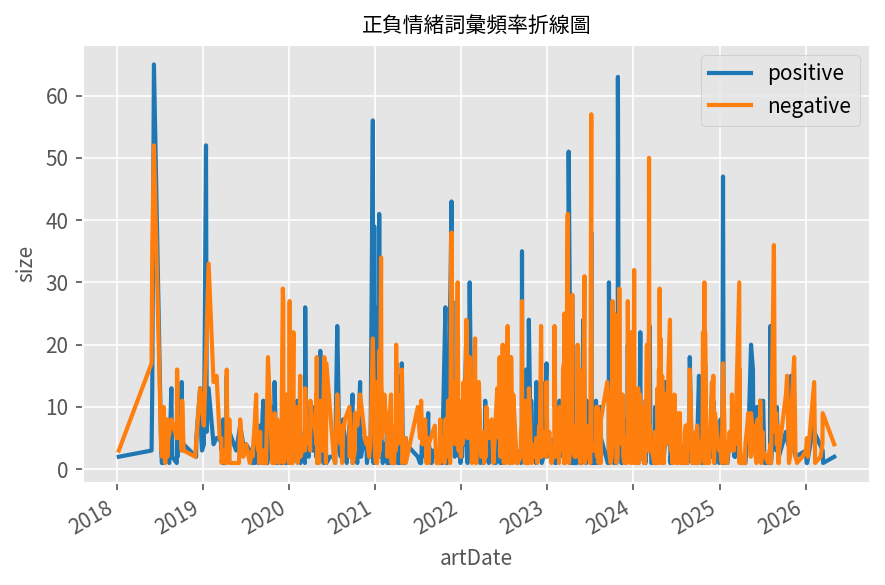

In [ ]:
import matplotlib.pyplot as plt
import urllib.request
import os

# 下載字體到 Colab
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"
font_path = "/usr/share/fonts/NotoSansCJKjp-Regular.otf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

# 載入字體
from matplotlib import font_manager
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 你的程式碼
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

plot_sentiment_trend(pos, neg, "正負情緒詞彙頻率折線圖")

正負向情緒詞彙頻率時間序列平滑化

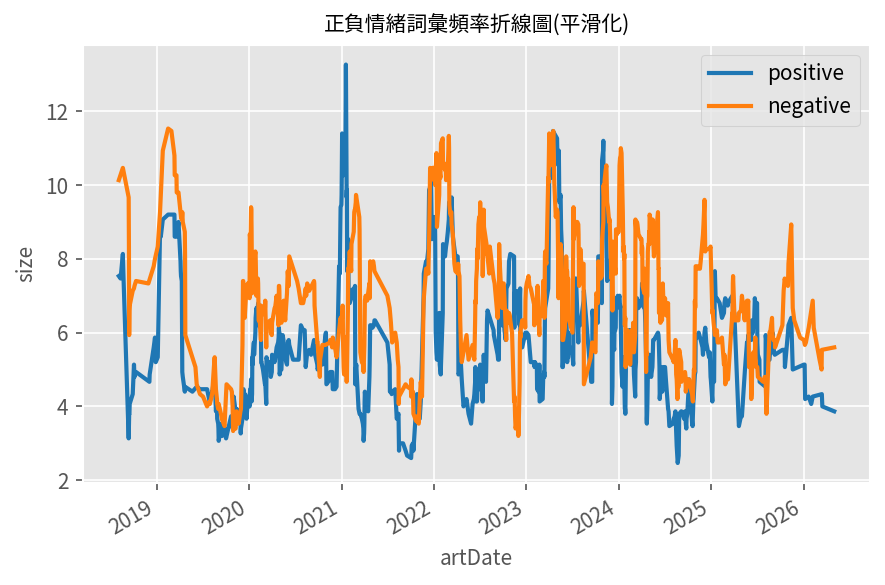

In [ ]:
rolling_days = 15
plot_sentiment_trend(pos, neg, "正負情緒詞彙頻率折線圖(平滑化)", meanDay=rolling_days)

### 正負情緒詞彙比例折線圖

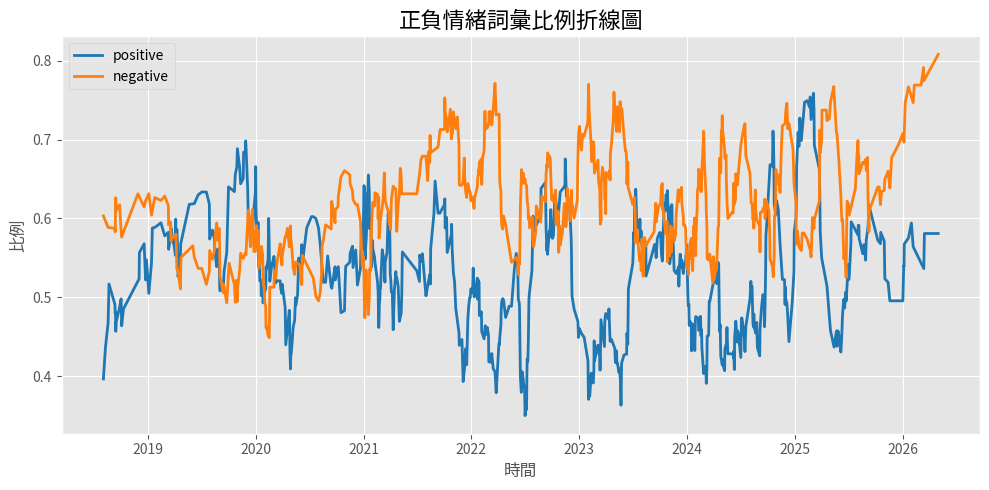

In [ ]:
def plot_sentiment_ratio(pos, neg, title_name, meanDay=None):
    colors = ["#1f77b4", "#ff7f0e"]  # 加上這行：藍色=正面, 橘色=負面

    fig, ax = plt.subplots(figsize=(10, 5))

    if meanDay:
        pos_y = pos['ratio'].rolling(meanDay).mean()
        neg_y = neg['ratio'].rolling(meanDay).mean()
    else:
        pos_y = pos['ratio']
        neg_y = neg['ratio']

    ax.plot(pos["artDate"], pos_y, color=colors[0], label="positive", linewidth=2)
    ax.plot(neg["artDate"], neg_y, color=colors[1], label="negative", linewidth=2)

    ax.set_title(title_name, fontsize=16)
    ax.set_xlabel("時間")
    ax.set_ylabel("比例")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 執行
pos_ratio = sentiment_ratio[sentiment_ratio["sentiments"] == "positive"]
neg_ratio = sentiment_ratio[sentiment_ratio["sentiments"] == "negative"]

plot_sentiment_ratio(pos_ratio, neg_ratio, "正負情緒詞彙比例折線圖", meanDay=rolling_days)

### 正負向情緒分數折線圖

透過 Pivot 將每日正向與負向情緒整併至同一列，使其可直接進行相減運算，以計算情緒差值。

In [ ]:
sentiment_value = (
    sentiment_ratio.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value.head()

,artDate,negative,positive
0,2018-01-08,3.0,2.0
1,2018-05-27,17.0,3.0
2,2018-05-30,36.0,13.0
3,2018-06-06,52.0,65.0
4,2018-07-07,3.0,3.0


情緒分數折線圖平滑化

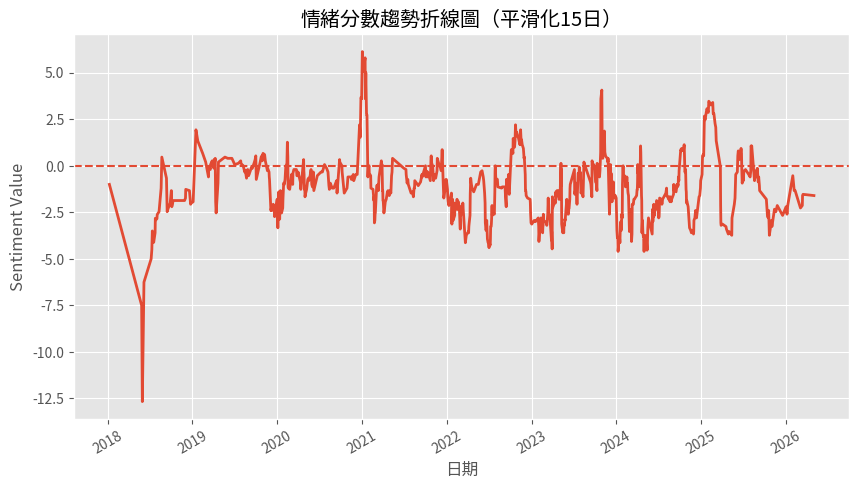

In [ ]:
def plot_sentiment_net_trend(df, window=15):
    import matplotlib.pyplot as plt

    y = df["sentiment_value"].rolling(window, min_periods=1).mean()

    plt.figure(figsize=(10,5))
    plt.plot(df["artDate"], y, linewidth=2)

    # 中線（0）
    plt.axhline(0, linestyle="--")

    plt.title(f"情緒分數趨勢折線圖（平滑化{window}日）")
    plt.xlabel("日期")
    plt.ylabel("Sentiment Value")

    plt.xticks(rotation=30)
    plt.show()

sentiment_value["sentiment_value"] = (
    sentiment_value["positive"] - sentiment_value["negative"]
)
sentiment_value = sentiment_value.sort_values("artDate")
plot_sentiment_net_trend(sentiment_value)


## 3.3 正負文章趨勢分析

### 計算每篇文章中正面和負面詞彙數

In [ ]:
sentiment_count = pd.DataFrame(
    liwc_df.groupby(["system_id", "sentiments"]).size()
).reset_index()
sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count.head()

,system_id,sentiments,size
0,1,affect,20
1,1,anx,1
2,1,negative,17
3,1,positive,3
4,1,sad,3


### 區分文章正負面傾向

In [ ]:
# pivot 以 system_id 為單位整理正負情緒
sentiment_value = (
    sentiment_count.pivot_table(
        index="system_id",
        columns="sentiments",
        values="size",
        fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# 計算情緒分數
sentiment_value["sentiment_value"] = (
    sentiment_value["positive"] - sentiment_value["negative"]
)

# 情緒分類
sentiment_value["sentiment_class"] = (
    sentiment_value["sentiment_value"]
    .apply(lambda x: "正向" if x > 0 else "負向")
)

# 顯示結果
sentiment_value.head()

,system_id,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,1,20.0,0.0,1.0,17.0,3.0,3.0,-14.0,負向
1,2,13.0,0.0,1.0,8.0,5.0,3.0,-3.0,負向
2,3,19.0,0.0,0.0,3.0,14.0,1.0,11.0,正向
3,5,5.0,0.0,0.0,1.0,4.0,0.0,3.0,正向
4,7,26.0,0.0,1.0,15.0,11.0,0.0,-4.0,負向


資料合併

In [ ]:
# 把每篇文章的情緒類別合併回原始資料
merge_df_sentiment = pd.merge(
    clear_df[['system_id', 'artTitle', 'artDate', 'artContent']],
    sentiment_value[['system_id', 'sentiment_class']],
    on="system_id",
    how="left"
)
# 清除沒有情緒資料的文章
merge_df_sentiment = merge_df_sentiment.dropna(subset=["sentiment_class"])

# 確保 artDate 是 datetime 格式 並只保留日期
merge_df_sentiment["artDate"] = pd.to_datetime(merge_df_sentiment["artDate"])
merge_df_sentiment["artDate"] = merge_df_sentiment["artDate"].dt.date

# 顯示結果
merge_df_sentiment.head(10)

,system_id,artTitle,artDate,artContent,sentiment_class
0,1,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,負向
1,2,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,負向
2,3,Re:[新車]GSX-R150,2018-10-02,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。\n你的定位是平日通勤、假日跑山，那你的...,正向
4,5,[新聞]防範南迴舊台9線成另條北宜公路區間速率,2019-03-27,新聞來源 自由時報\nhttps://news.ltn.com.tw/news/life/b...,正向
6,7,[新聞]北宜區間測速執法至今機車違規最多,2019-04-11,記者游承霖／新北報導\n\n 近年來北宜公路重大死傷車禍頻傳，新北市政府警察局...,負向
7,8,[分享]幫機車取名字而跑去24耐是否搞錯了什麼,2019-04-21,小弟座駕 消光藍 Jet S\n\n其實這是一篇掛羊頭賣狗肉的文章，\n美其名叫幫我家小藍取...,正向
9,10,[閒聊]自強隧道區間測速開始安裝,2019-04-23,https://forum.jorsindo.com/thread-2540975-1-1....,負向
11,12,Fw:[臉書]林國春-板橋區議員,2019-06-20,作者: Goldens (生命) 看板: Gossiping\n標題: [臉書] 林國春-板...,正向
12,13,Fw:[新聞]重機族小心！「聲音照相」大執法上路 呼,2019-07-02,作者: BDrip (藍光~) 看板: Gossiping\n標題: [新聞] 重機族小心！...,負向
14,15,[分享]提醒明天自強隧道正式開始區間測速,2019-08-31,警方那邊已經在fb正式公告了\n\n各位駕駛人注意囉!!.....................,負向


In [ ]:
sentiment_count = pd.DataFrame(
    merge_df_sentiment.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])

sentiment_count.head(10)

,artDate,sentiment_class,size
0,2018-01-08,負向,1
1,2018-05-27,負向,1
2,2018-05-30,負向,4
3,2018-06-06,正向,1
4,2018-07-07,負向,1
5,2018-07-10,負向,1
6,2018-07-11,正向,1
7,2018-07-11,負向,1
8,2018-07-12,負向,1
9,2018-07-18,負向,1


### 正負文章數趨勢折線圖

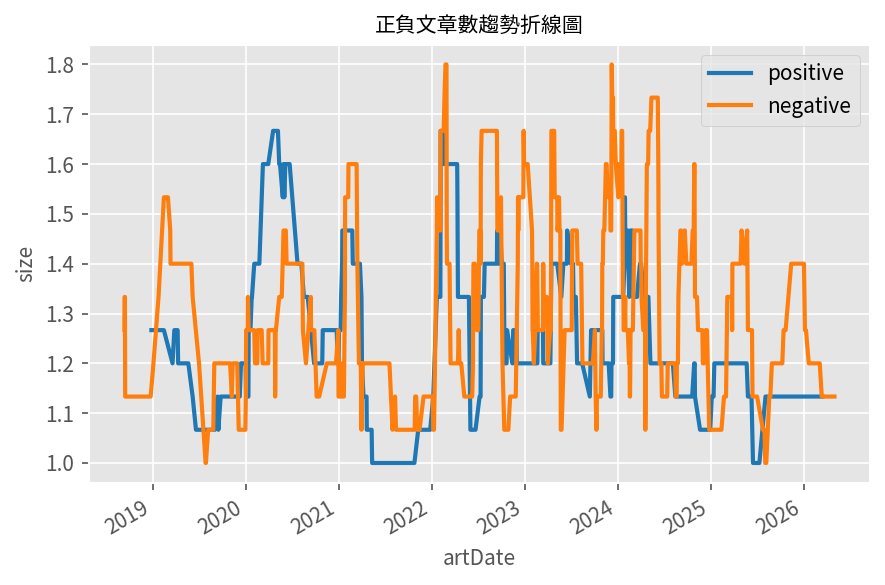

In [ ]:
pos = sentiment_count[sentiment_count["sentiment_class"] == "正向"]
neg = sentiment_count[sentiment_count["sentiment_class"] == "負向"]

plot_sentiment_trend(pos, neg, "正負文章數趨勢折線圖", meanDay=rolling_days)

## 3.4 正負情緒關鍵字

In [ ]:
# 長條圖格式設定
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字型
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
font_prop = fm.FontProperties(fname=font_path)

# 顯示前 20 名
obs = 20

def plot_sentiment_word_bar(pos, neg):

    # 取前幾名
    pos = pos.head(obs)
    neg = neg.head(obs)

    # 建立圖表
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # 正向詞
    axes[0].barh(pos["word"], pos["size"], color="#1f77b4")
    axes[0].set_title("正向詞 Top", fontproperties=font_prop)
    axes[0].invert_yaxis()

    # 負向詞
    axes[1].barh(neg["word"], neg["size"], color="#ff7f0e")
    axes[1].set_title("負向詞 Top", fontproperties=font_prop)
    axes[1].invert_yaxis()

    # 中文字型
    for ax in axes:
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.show()

In [ ]:
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm
import os

def get_cjk_font():
    candidates = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
    ]
    for path in candidates:
        if os.path.exists(path):
            return FontProperties(fname=path)

    # Fall back to any available font with CJK support
    for f in fm.fontManager.ttflist:
        if any(k in f.fname for k in ['CJK', 'Noto', 'WenQuanYi']):
            if os.path.exists(f.fname):
                return FontProperties(fname=f.fname)

    return FontProperties()  # matplotlib default as last resort

font_prop = get_cjk_font()

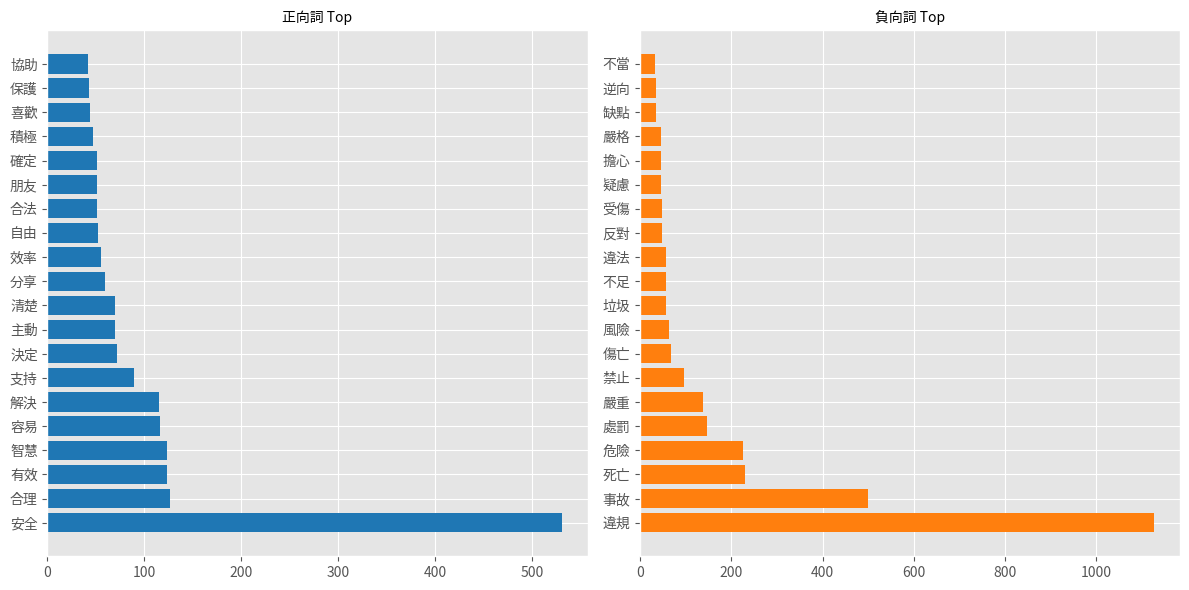

In [ ]:
word_count = liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_neg = word_count.loc[(word_count["sentiments"] == "negative")]

obs = 20

pos = word_pos.head(obs).sort_values(["size"], ascending=True)
neg = word_neg.head(obs).sort_values(["size"], ascending=True)
plot_sentiment_word_bar(pos, neg)

In [ ]:
filtered_df = sent_df[sent_df['sentence'].str.contains('節能', na=False)]
filtered_df[["sentence"]].reset_index(drop=True)

,sentence
0,媽的減低三寶開內線機率真的想開過陣子吊照節能減碳三寶乖乖不能上路過年長假保證不塞篩選不及格駕駛爽啦


## 3.5 重新計算情緒

In [ ]:
# 設定要移除的電動車相關雜訊詞
words_to_remove = [

    # 品牌 / 車型
    '特斯拉', 'Tesla', '比亞迪', 'Model',

    # 產業通用詞
    '電動車', '新能源車', '車款', '新車',
    '汽車', '車主', '品牌',

    # 規格詞
    '續航', '里程', '公里', '充電',
    '電池', '快充',

    # 市場新聞常見詞
    '市場', '銷量', '上市', '價格',
    '表示', '指出', '認為', '消息',

    # 地區詞
    '台灣', '中國', '美國',

    # 刪除
    '連結'
]

# 修訂字典，過濾指定字詞
liwc_dict_revise = liwc_dict[
    ~liwc_dict['word'].isin(words_to_remove)
]

# merge
liwc_df_revise = pd.merge(
    noStop_df2[["system_id", "artDate", "artTitle", "artContent", "word"]],
    liwc_dict_revise,
    how="left"
)

# 真正移除指定字詞
liwc_df_revise = liwc_df_revise[
    ~liwc_df_revise['word'].isin(words_to_remove)
]

# 移除英文詞
liwc_df_revise = liwc_df_revise[
    ~liwc_df_revise['word'].str.contains(r'[A-Za-z]', na=False)
]

# 日期只保留到日
liwc_df_revise['artDate'] = (
    pd.to_datetime(liwc_df_revise['artDate'])
      .dt.normalize()
)

# 查看結果
liwc_df_revise.head()

,system_id,artDate,artTitle,artContent,word,Unnamed: 0,sentiments
0,1,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,彎道,NaN,NaN
1,1,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡,NaN,affect
2,1,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,死亡,NaN,negative
3,1,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,人數,NaN,NaN
4,1,2018-05-27,[新聞]北宜彎道死亡人數「飆」新高,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,新高,NaN,NaN


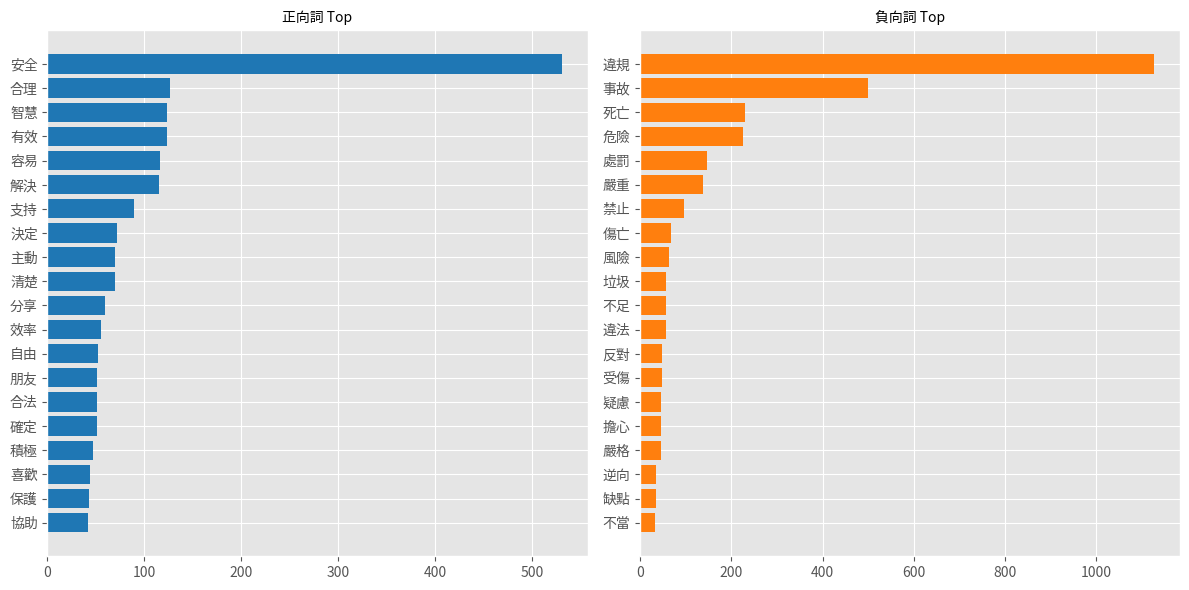

In [ ]:
word_count_revise = liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count_revise = word_count_revise.rename(columns={0: "size"})
word_count_revise = word_count_revise.sort_values(["size"], ascending=False)

word_of_pos_revise = word_count_revise.loc[(word_count_revise["sentiments"] == "positive")]
word_of_neg_revise = word_count_revise.loc[(word_count_revise["sentiments"] == "negative")]

pos_revise = word_of_pos_revise.head(obs).sort_values(["size"], ascending=True)
neg_revise = word_of_neg_revise.head(obs).sort_values(["size"], ascending=True)

plot_sentiment_word_bar(word_of_pos_revise, word_of_neg_revise)

### 重新繪製情緒分數趨勢圖

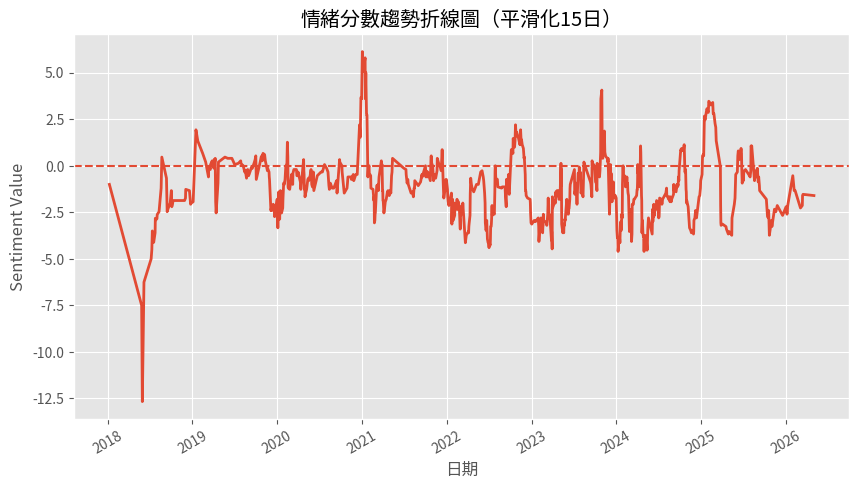

In [ ]:
sentiment_count_revise = pd.DataFrame(
    liwc_df_revise.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_revise['sentiments'] == "positive") | (sentiment_count_revise['sentiments'] == "negative")
sentiment_count_revise = sentiment_count_revise.loc[mask]

sentiment_count_revise = sentiment_count_revise.rename(columns={0: "size"})
sentiment_count_revise = sentiment_count_revise.sort_values(["artDate"])

sentiment_value_revise = (
    sentiment_count_revise.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

sentiment_value_revise["sentiment_value"] = (
    sentiment_value_revise["positive"] - sentiment_value_revise["negative"]
)

plot_sentiment_net_trend(sentiment_value_revise, rolling_days)

## 3.6 負面文章的文字雲

###計算負面文章詞頻

In [ ]:
# 將文章情緒分類 merge 回原資料
liwc_df_revise = pd.merge(
    liwc_df_revise,
    sentiment_value[['system_id', 'sentiment_class']],
    on='system_id',
    how='left'
)

# 只保留負向文章
neg_df = liwc_df_revise[
    liwc_df_revise['sentiment_class'] == '負向'
]

# 計算詞頻
word_count_neg = (
    neg_df.groupby('word')
    .size()
    .reset_index(name='size')
    .sort_values(by='size', ascending=False)
)

# 顯示前 20 個詞
word_count_neg.head(20)

,word,size
13564,違規,2044
10220,科技執法,1005
896,事故,864
1049,交通,813
2798,區間測速,708
3124,取締,690
12704,路口,686
12727,路段,659
12616,超速,528
4675,安全,524


### 繪製負面文章文字雲

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 中文字型
font_path = "/usr/share/fonts/NotoSansCJKjp-Regular.otf"

def plot_wordcloud(word_df, title, top_n=100):

    # 前 N 個詞
    top_words = word_df.head(top_n)

    # 建立詞頻 dictionary
    word_dict = dict(
        zip(top_words['word'], top_words['size'])
    )

    # 文字雲
    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        colormap='Oranges',
        width=1200,
        height=600,
        max_words=top_n,
        random_state=42
    ).generate_from_frequencies(word_dict)

    # 繪圖
    plt.figure(figsize=(14, 7))

    plt.imshow(wc)

    plt.axis('off')

    plt.title(
        title,
        fontsize=20
    )

    plt.show()

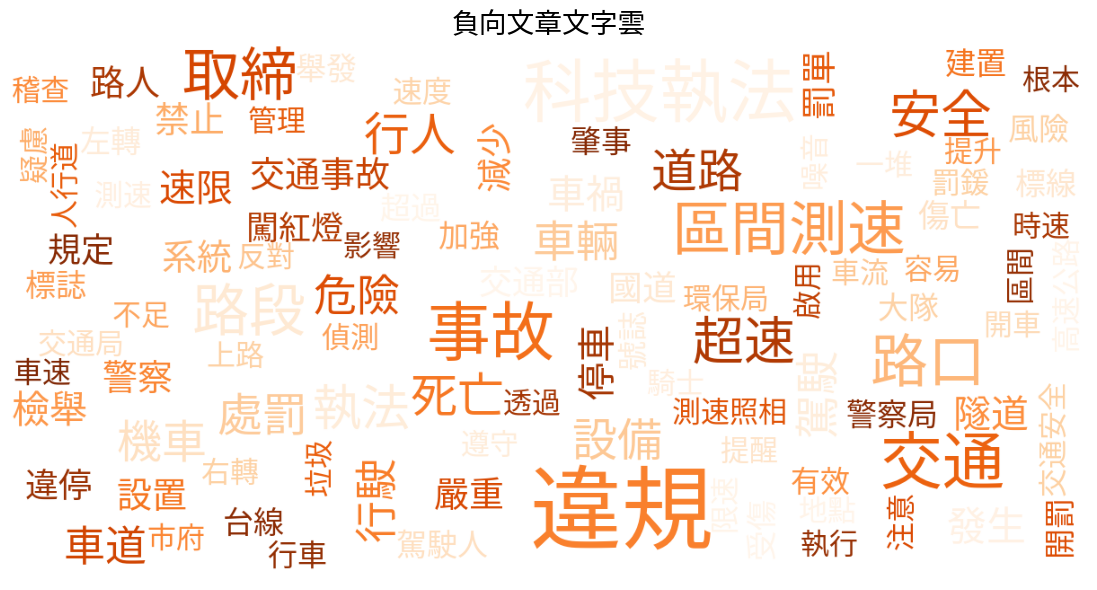

In [ ]:
plot_wordcloud(word_count_neg, "負向文章文字雲")

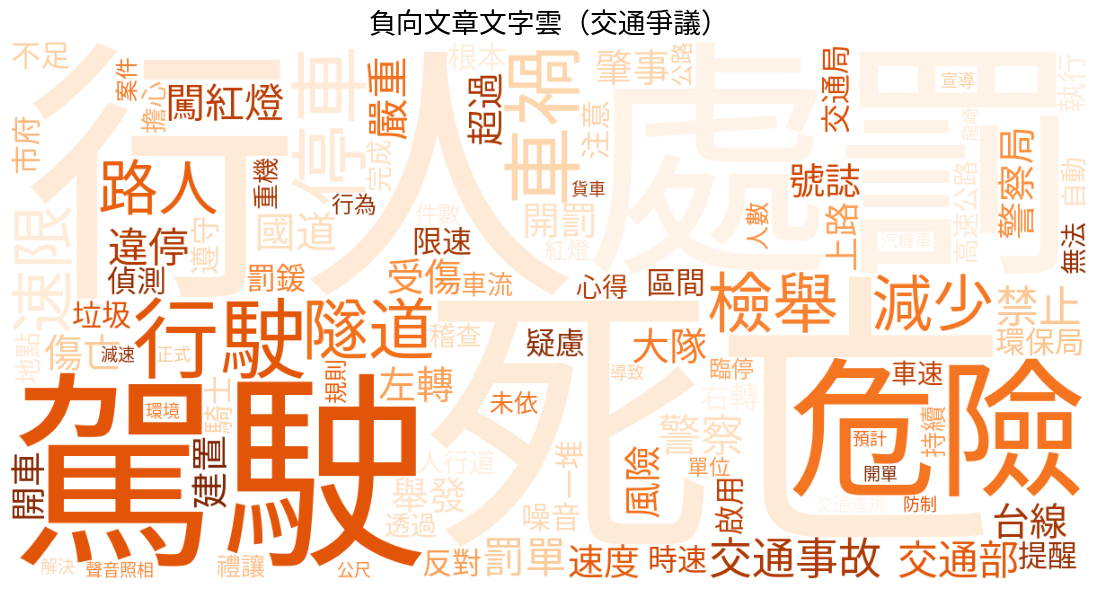

In [ ]:
# 排除低資訊量詞彙
words_to_exclude = [

   # 主題框架詞
    '交通',
    '道路',
    '路段',
    '區間測速',
    '科技執法',
    '執法',
    '取締',
    '測速',
    '測速照相',
    '交通安全',

    # 泛交通詞
    '違規',
    '超速',
    '事故',
    '安全',
    '車輛',
    '機車',
    '汽車',
    '行車',
    '駕駛人',
    '車道',
    '路口',

    # 泛政策詞
    '管理',
    '規定',
    '設置',
    '系統',
    '設備',
    '標誌',
    '標線',

    # 太泛的效果詞
    '有效',
    '提升',
    '加強',
    '容易',
    '影響',
    '發生'
]
# 過濾詞彙
word_count_neg_filtered = word_count_neg[
    ~word_count_neg['word'].isin(words_to_exclude)
]
# 繪製文字雲
plot_wordcloud(
    word_count_neg_filtered,
    title="負向文章文字雲（交通爭議）",
    top_n=100
)

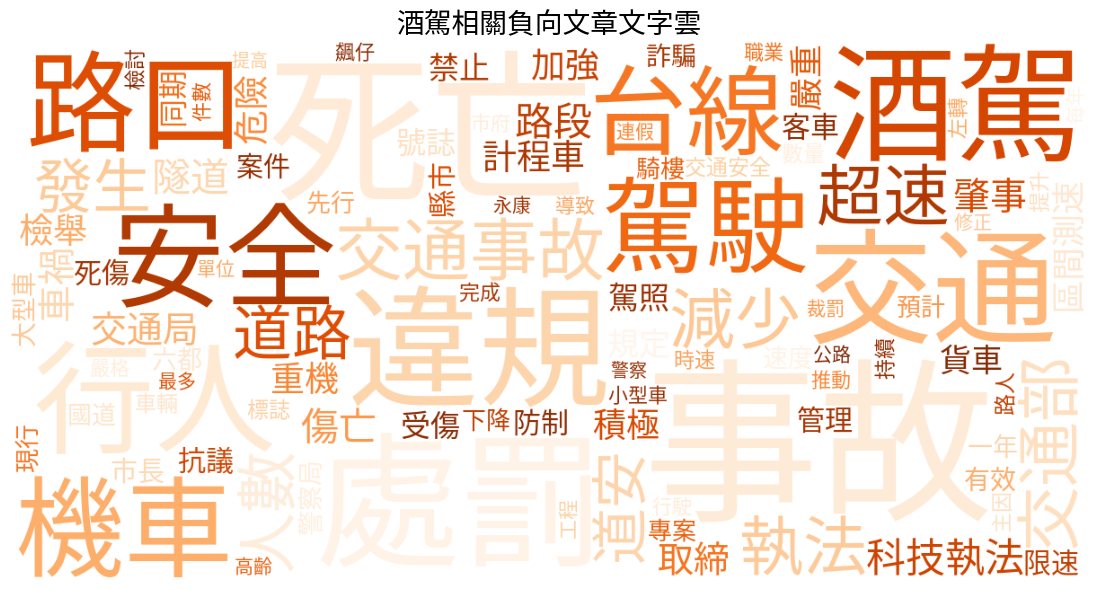

In [ ]:
# 找出包含「」的文章
explode_articles = liwc_df_revise[
    liwc_df_revise['word'].str.contains('酒駕', na=False)
]['system_id'].unique()

explode_neg_df = liwc_df_revise[
    (liwc_df_revise['system_id'].isin(explode_articles)) &
    (liwc_df_revise['sentiment_class'] == '負向')
]

# 計算詞頻
word_count_explode_neg = (
    explode_neg_df.groupby('word')
    .size()
    .reset_index(name='size')
    .sort_values(by='size', ascending=False)
)

# 繪製文字雲
plot_wordcloud(
    word_count_explode_neg,
    "酒駕相關負向文章文字雲"
)

從爆炸相關負向文章的文字雲可以發現，負面情緒已不僅集中於「爆炸」或「起火」事件本身，而是進一步延伸至保險、停車場、系統故障與車體損壞等次級風險議題。其中，「保險」、「停車場」、「車體險」、「損壞」等詞彙頻繁出現，顯示民眾對於電動車事故後續衍生的經濟成本與公共安全問題具有高度疑慮。此外，「系統」、「降低」、「強烈」等詞彙也反映出消費者對電動車安全性與可靠性的負面感受。整體而言，電動車爆炸相關新聞已不只是單一事故事件，而是逐漸形成對保險負擔、公共空間安全與車輛風險管理的社會性焦慮。


# 4. 情緒分析 Part2

## 4.1 套件安裝

In [ ]:
!pip install ckiptagger[tf,gdown] snownlp

In [ ]:
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import re
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime

### 套件說明 + 載入套件

## 4.2 CKIP處理

### 載入 CKIP 模型

In [ ]:
#!pip install -U gdown

#import gdown

#folder_url = "https://drive.google.com/drive/folders/1qU_aXSTxIhTlsZrKcG6JLX-uQW5VYhoj?usp=sharing"

#gdown.download_folder(
    #url=folder_url,
    #output="data",
    #quiet=False,
    #use_cookies=False
#)

In [ ]:
# 將三份工具的模型路徑指向我們剛才下載的檔案「data」
#ws = WS("/content/data")
#pos = POS("/content/data")
#ner = NER("/content/data")

### 定義文字清理函式

In [ ]:
## 讀取文章
df3 = pd.read_csv('/content/car.csv')
df3.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27 06:18:33,cute320518,biker,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Tudo11927"", ...",117.19.182.204,2018-06-10 14:01:38,ptt
1,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27 02:51:52,strellson,biker,https://tw.news.appledaily.com/life/realtime/2...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""SSSONIC"", ""c...",101.136.200.246,2018-10-08 02:30:52,ptt
2,3,https://www.ptt.cc/bbs/biker/M.1538495370.A.4F...,Re:[新車]GSX-R150,2018-10-02 15:43:28,elynn889,biker,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。\n你的定位是平日通勤、假日跑山，那你的...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""tsukie2887"",...",114.35.25.145,2018-10-08 02:31:06,ptt


In [ ]:
df3 = df3.copy()
df3['artContent'] = df3['artContent'].fillna('').astype(str)


In [ ]:
def Segmentation_Core(data, tokenizer):
    # 將所有的斷行字元配上 escape 以防失效
    regexPattern = '|'.join(map(re.escape, tokenizer))
    output_list = re.split(regexPattern, data)
    # 過濾空白行
    output_list = list(filter(None, output_list))
    return output_list

def Sentence_Segmentation(article, keep_digits=False, keep_alphabets=False):
    """ Sentence_Segmentation function 用於執行中文斷行任務

    順序如下：
    1. 去除(\\n)
    2. 去除特殊符號字元
    3. 保留數字
    4. 依照斷句字元進行斷句全形的分號、逗號、句號、問號以及驚嘆號
    5. 避免空白斷句結果

    Args:
        article(string): 欲斷行之文章內容
        keep_digits(Boolean): 決定是否保留數字於斷行後的結果
        keep_alphabets(Boolean): 決定是否保留字母於斷行後的結果
    Returns:
        List [] 每個 element 就是一行
    """
    sepical_symbols = r'[.＂/<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：\
    ＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—一‘’‛“”„‟…‧﹏★→─]+'
    segmentation_used_note = (";", "；", "！", "!", "？", "?", "。")


    paragraphs = list(filter(lambda x: re.sub(r'\s+','', x), article.split("\n")))
    # print(len(paragraphs))
    # print(paragraphs)

    result = []
    for paragraph in paragraphs:

        clean_paragraph = paragraph
        try:
            if not keep_digits:
                clean_paragraph = re.sub(r'\d*\.?\d+','', clean_paragraph) #remove space & digits
            if not keep_alphabets:
                clean_paragraph = re.sub('[a-zA-Z]+', '', clean_paragraph)

            clean_paragraph = re.sub(r'[\s]+','', clean_paragraph) #remove space

            clean_paragraph = re.sub(sepical_symbols,'',clean_paragraph)

        except:
            return "error"

        res = Segmentation_Core(clean_paragraph, segmentation_used_note)
        result.append(res)

    return result

### 定義 CKIP 處理函式 + 自訂辭典

In [ ]:
from ckiptagger import construct_dictionary

# 如果你是用 gdown 下載整個資料夾到 data，路徑可能是：
# user_dict_path = "/content/data/user_dict.txt"

# 如果你的檔案就在 /content 底下，用這個：
user_dict_path = "/content/user_dict.txt"

with open(user_dict_path, "r", encoding="utf-8") as f:
    lines = f.read().splitlines()

user_dict = {}

for line in lines:
    line = line.strip()

    # 跳過空白行
    if not line:
        continue

    parts = line.split()

    # 情況 1：一行只有詞，例如：道路設計
    if len(parts) == 1:
        word = parts[0]
        weight = 1

    # 情況 2：一行有詞和權重，例如：道路設計 2
    else:
        word = parts[0]
        try:
            weight = float(parts[1])
        except ValueError:
            weight = 1

    user_dict[word] = weight

dictionary = construct_dictionary(user_dict)

print(user_dict)
print(dictionary)

{'科技執法': 1, '區間測速': 1, '區間速率': 1, '平均速率': 1, '測速照相': 1, '聲音照相': 1, '車牌辨識': 1, '辨識系統': 1, '科技設備': 1, '固定測速': 1, '活動式測速': 1, '噪音偵測': 1, '交通安全': 1, '交通事故': 1, '交通違規': 1, '道路安全': 1, '道路設計': 1, '駕駛行為': 1, '防禦駕駛': 1, '行車安全': 1, '安全距離': 1, '車流量': 1, '超速違規': 1, '違規行為': 1, '科技取締': 1, '教育宣導': 1, '政策推動': 1, '政府部門': 1, '交通部': 1, '公路總局': 1, '高公局': 1, '警察局': 1, '縣警局': 1, '環保署': 1, '大型重機': 1, '重型機車': 1, '快速道路': 1, '高速公路': 1, '北宜公路': 1, '南迴公路': 1, '蘇花改': 1, '雙黃線': 1, '禁行機車': 1, '側車道': 1, '機車道': 1, '噪音車': 1, '改裝排氣管': 1, '噪音管制': 1, '噪音車輛': 1, '排氣管': 1, '噪音檢測': 1, '分貝標準': 1, '跑山': 1, '壓車': 1, '路權': 1, '黃牌': 1, '紅牌': 1, '白牌': 1, '騎士文化': 1, '防衛駕駛': 1, '行車紀錄器': 1, '交通工程': 1, '道路速限': 1, '區間平均': 1, '平均車速': 1, '測速路段': 1, '測速區間': 1, '超速取締': 1, '科技警政': 1, '智慧交通': 1, '交通科技': 1}
[(2, {'跑山': 1.0, '壓車': 1.0, '路權': 1.0, '黃牌': 1.0, '紅牌': 1.0, '白牌': 1.0}), (3, {'車流量': 1.0, '交通部': 1.0, '高公局': 1.0, '警察局': 1.0, '縣警局': 1.0, '環保署': 1.0, '蘇花改': 1.0, '雙黃線': 1.0, '側車道': 1.0, '機車道': 1.0, '噪音車': 1.0, '排氣管': 1.0}), (4, {'科技執法': 1

In [ ]:
def get_pos(post_id, word_sentence, pos_sentence):
    tokens = []
    # print("\nPOS: ", end="\u3000")
    assert len(word_sentence) == len(pos_sentence)
    for word, pos in zip(word_sentence, pos_sentence): # token level
        tokens.append([post_id, word, pos])
    # print(f"{word}({pos})", end="\u3000")
    return tokens

def get_ner(post_id, entity_sentence):
    entities = []
    # print("\nNER:___________ ")
    for entity in sorted(entity_sentence): # token level
        entities.append([post_id, entity[3], entity[2]])
    return entities

def get_nlp_result(data_df):
    start = time.time()

    pos_list = []
    entity_list = []
    sentence_list = []

    # 遍歷 dataframe 的每筆資料
    for index, row in data_df.iterrows(): # document level
    # print(f"\ndocument {index}")

        # 資料清理 ＆ 斷句
        tmp = Sentence_Segmentation(row['artContent'])
        flat_list = [item for sublist in tmp for item in sublist]

        # ckip
        word_sentence_list = ws(flat_list, coerce_dictionary = dictionary)
        pos_sentence_list = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        # 遍歷該 document 中的每一個句子
        for i, sentence in enumerate(flat_list):
            # print(f"sentence {i}: {sentence}")
            sentence_list.append([row['system_id'], sentence])
            temp_tokens = get_pos(row['system_id'], word_sentence_list[i], pos_sentence_list[i])
            temp_entites = get_ner(row['system_id'], entity_sentence_list[i])

            pos_list.append(temp_tokens)
            if len(temp_entites) != 0:
                entity_list.append(temp_entites)

    pos_flat = [item for sublist in pos_list for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table = pd.DataFrame(data=pos_flat,
                    columns=['system_id','word','pos'])

    entity_table = pd.DataFrame(data=entity_flat,
                        columns=['system_id','word','ner'])

    sentence_table = pd.DataFrame(data=sentence_list,
                    columns=['system_id','sentence'])

    end = time.time()
    print("time costing: {}".format(end - start))

    return pos_table, entity_table, sentence_table

In [ ]:
# 看看 tmp 和 flat_list 有什麼差別
tmp = Sentence_Segmentation(df3['artContent'][0])
flat_list = [item for sublist in tmp for item in sublist]
print(tmp[:5])
print(flat_list[:5])

[['北宜彎道死亡人數飆新高'], [], ['騎士自摔亡今年已死'], ['記者陳薏云新北報導'], ['北宜公路是知名危險山路，前年新北段死亡人去年升至人']]
['北宜彎道死亡人數飆新高', '騎士自摔亡今年已死', '記者陳薏云新北報導', '北宜公路是知名危險山路，前年新北段死亡人去年升至人', '，大都是機車騎士，今年更多，包括昨天又有名騎士自摔後被大貨車輾斃，這個多月']


### 執行 CKIP 標註

In [ ]:
#註解下面程式，因已執行後匯出結果避免執行過久。
#pos_table, entity_table, sentence_table = get_nlp_result(df3)


In [ ]:
# 讀取已經執行完畢的結果
pos_table = pd.read_csv("/content/pos_table_buffet.csv")
entity_table = pd.read_csv("/content/entity_table_buffet.csv")
sentence_table = pd.read_csv("/content/sentence_table_buffet.csv")

In [ ]:
pos_table.head() # word pos 列表

,system_id,word,pos
0,1,北宜,Nc
1,1,彎道,Na
2,1,死亡,VH
3,1,人數,Na
4,1,飆,VHC


In [ ]:
entity_table.head() # word entity 列表

,system_id,word,ner
0,1,北宜,GPE
1,1,今年,DATE
2,1,陳薏云,PERSON
3,1,新北,GPE
4,1,北宜公路,FAC


In [ ]:
sentence_table.head()

,system_id,sentence
0,1,北宜彎道死亡人數飆新高
1,1,騎士自摔亡今年已死
2,1,記者陳薏云新北報導
3,1,北宜公路是知名危險山路，前年新北段死亡人去年升至人
4,1,，大都是機車騎士，今年更多，包括昨天又有名騎士自摔後被大貨車輾斃，這個多月


In [ ]:
# 檢查筆數
print(f"total posts numbers: {len(pos_table['system_id'].unique())}") # 1433篇文
print(f"posts have NER: {len(entity_table['system_id'].unique())}") # 1334篇有抓到ner

total posts numbers: 1433
posts have NER: 1334


## 4.3 探索分析 - NER

### NER 種類分析

In [ ]:
ner_count = entity_table.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count

,ner,count
4,GPE,5120
11,ORG,4026
1,DATE,2958
3,FAC,2590
13,PERSON,2589
0,CARDINAL,1910
7,LOC,1877
16,TIME,710
10,ORDINAL,465
8,MONEY,391


Text(0.5, 0, 'Frequency')

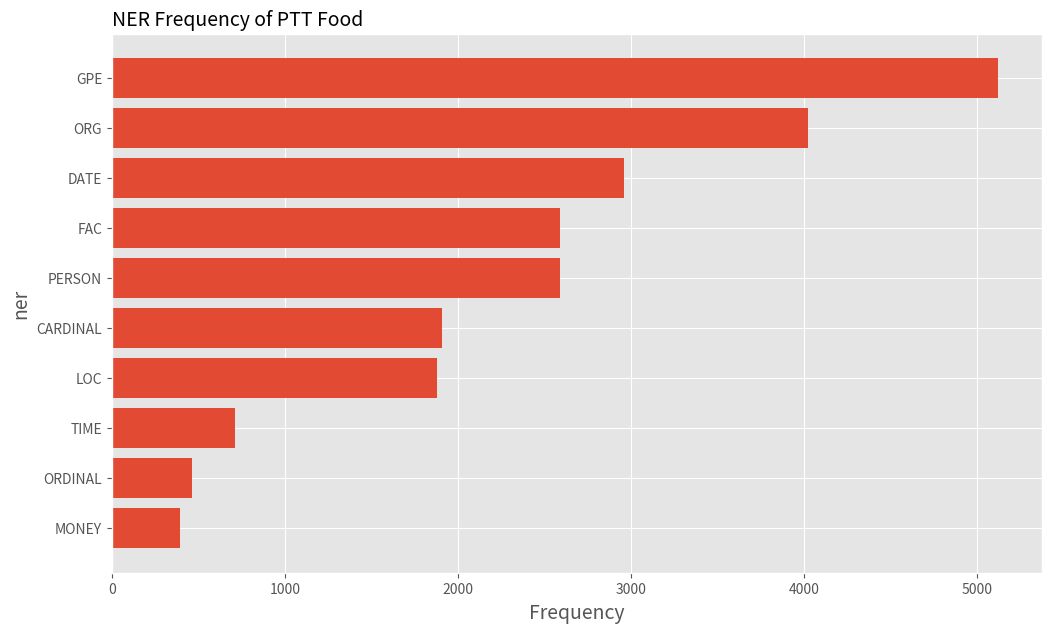

In [ ]:
ner = ner_count['ner']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(ner, count)
ax.invert_yaxis()
ax.set_title('NER Frequency of PTT Food',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
# fig.show()

### 涉及到的組織(ORG)

Text(0.5, 0, 'Word Frequency')

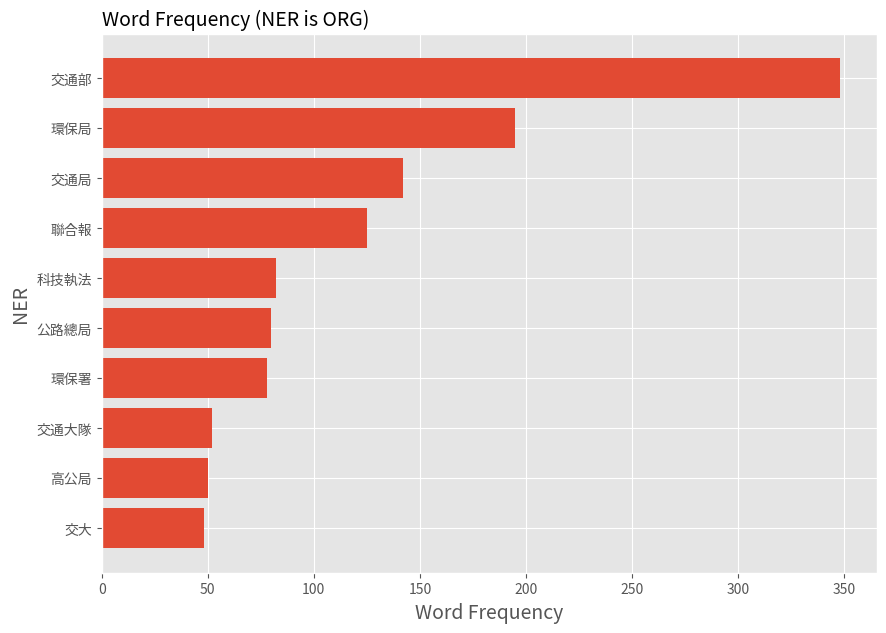

In [ ]:
# 篩選ner為ORG的資料
l_noun = ["ORG"]
ORG = entity_table[entity_table.ner.isin(l_noun)]

# # 計算每個名詞提到的次數，選出前10個
ner_count = ORG.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(10).reset_index()
ner_count

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is ORG)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

### 涉及到的人名(PERSON)

Text(0.5, 0, 'Word Frequency')

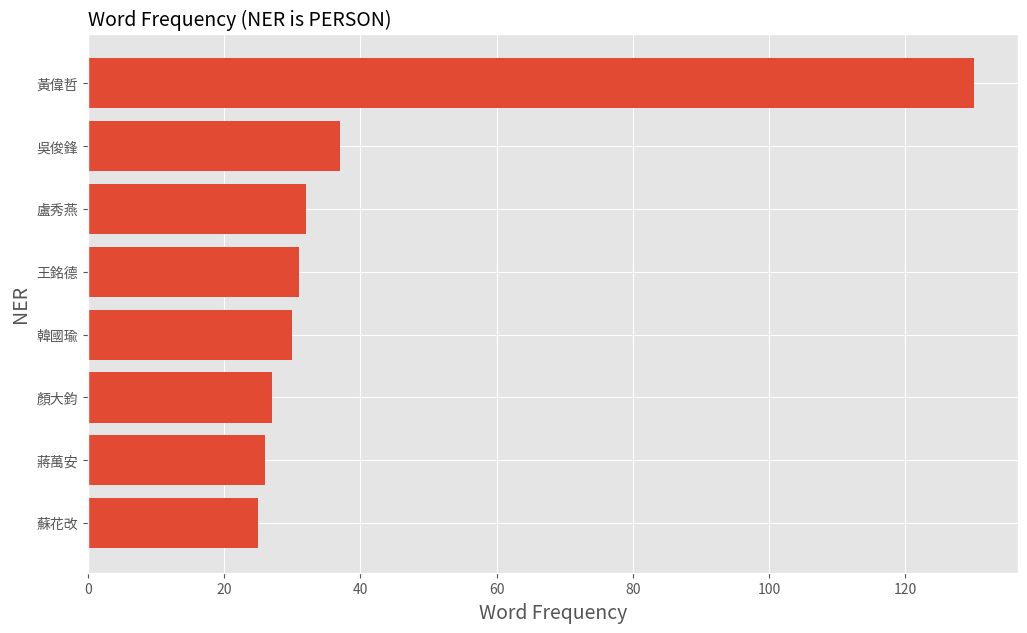

In [ ]:
# 篩選ner為PERSON的資料
l_noun = ["PERSON"]
PERSON = entity_table[entity_table.ner.isin(l_noun)]

# 計算每個名詞提到的次數，選出前8個
ner_count = PERSON.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(8).reset_index()

# 設定中文字形
word = ner_count['word']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is PERSON)',loc ='left', size = 14)
ax.set_ylabel('NER', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
# fig.show()

下面找出「科技執法」相關文章，與後續情緒分析一起做探索

In [ ]:
keyword_list = ['科技執法']
shu_selected = df[df['artContent'].str.contains('|'.join(keyword_list),regex=True)]
print(f"{' '.join(keyword_list)}：{shu_selected.shape[0]}篇相關貼文")
shu_selected.head(3)

科技執法：783篇相關貼文


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,cute320518,biker,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Tudo11927"", ...",117.19.182.204,2018-06-10 14:01:38,ptt
1,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,strellson,biker,https://tw.news.appledaily.com/life/realtime/2...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""SSSONIC"", ""c...",101.136.200.246,2018-10-08 02:30:52,ptt
3,4,https://www.ptt.cc/bbs/biker/M.1549095106.A.5E...,[閒聊]男大生騎白牌硬闖高架自摔倒地險遭輾頭,2019-02-02,wwf1588,biker,原文網址\nhttps://news.ebc.net.tw/News/Article/149...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""LieFang"", ""c...",101.136.29.178,2019-12-14 14:59:08,ptt


## 4.4 探索分析：POS

### POS 種類分析

In [ ]:
pos_table['pos'].unique()

array(['Nc', 'Na', 'VH', 'VHC', 'P', 'Nd', 'D', 'Nb', 'VE', 'SHI',
       'COMMACATEGORY', 'VCL', 'VK', 'Ng', 'VC', 'Nep', 'Nf', 'Neqb',
       'VJ', 'VA', 'T', 'Da', 'V_2', 'Neqa', 'Caa', 'Dfa', 'VL', 'Nes',
       'VG', 'Cbb', 'Ncd', 'DE', 'Neu', 'Cab', 'VF', 'A', 'Di', 'Nh',
       'Nv', 'VI', 'VD', 'Dk', 'VB', 'FW', 'VAC', 'Cba', 'I',
       'EXCLAMATIONCATEGORY', 'Dfb', 'DM', 'COLONCATEGORY',
       'PERIODCATEGORY', 'PARENTHESISCATEGORY', 'DASHCATEGORY',
       'PAUSECATEGORY'], dtype=object)

In [ ]:
pos_filter = pos_table[~pos_table.pos.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]

pos_count = pos_filter.groupby(['pos'])['pos'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count

,pos,count
17,Na,89905
5,D,43506
38,VC,34410
19,Nc,26548
44,VH,24094
31,P,16442
35,VA,15093
7,DE,12561
41,VE,10845
27,Nf,10358


#### POS 常見詞性列表
+ Na: 普通名詞
+ D: 副詞
+ VC: 動作及物動詞
+ Nb: 專有名詞
+ FW: 外文
+ VH: 狀態不及物動詞
+ Nh: 代名詞
+ DE: 的之得地
+ P: 介詞
+ VA: 動作不及物動詞
+ T: 語助詞
+ SHI: 是

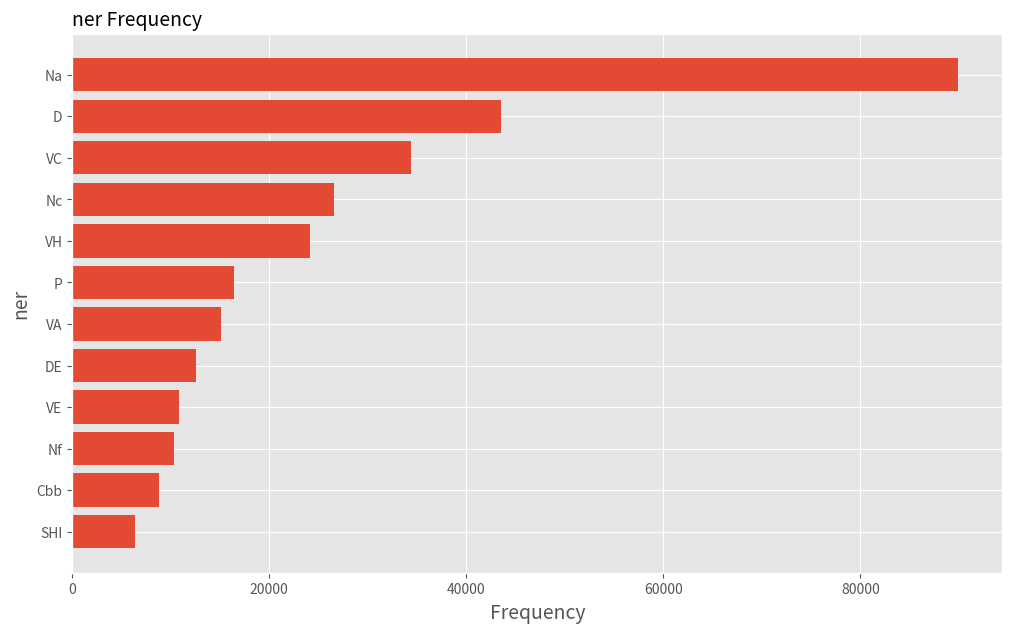

In [ ]:
pos = pos_count['pos']
count = pos_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(pos, count)
ax.invert_yaxis()
ax.set_title('ner Frequency',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
fig.show()

### 涉及到的名詞(Noun)
名詞可以分為「Na: 普通名詞」、「Nb: 專有名詞」等

In [ ]:
# 篩選pos為專有名詞的資料
l_noun = ["Nb"] #,"Na"
noun = pos_table[pos_table.pos.isin(l_noun)]

# 把長度為 1 的字去除
noun = noun[noun['word'].map(len) > 1]
# 計算每個名詞提到的次數，選出前15個
noun_count = noun[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
noun_count.head(10)

,word,count
926,聯合報,149
1429,黃偉哲,130
1042,蘇花改,76
940,自由時報,40
174,吳俊鋒,37
1109,資安,34
856,盧秀燕,32
825,王銘德,31
1364,韓國瑜,30
709,民進黨,28


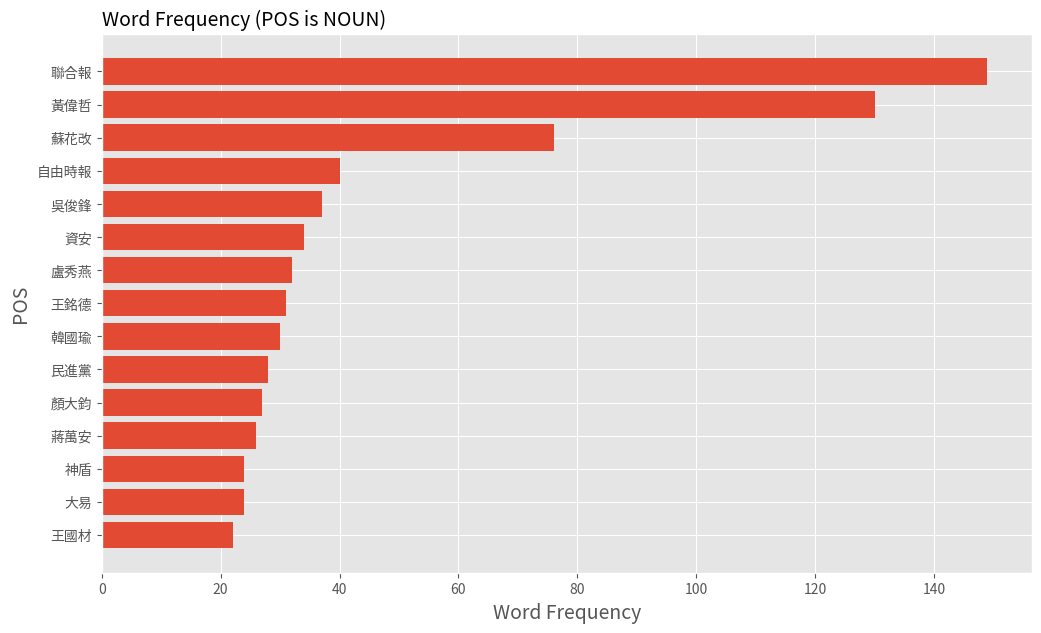

In [ ]:
# 設定中文字形
word = noun_count['word']
count = noun_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is NOUN)',loc ='left', size = 14)
ax.set_ylabel('POS', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

### 涉及到的動詞(VERB)
+ VC: 動作及物動詞、VH: 狀態不及物動詞、VA: 動作不及物動詞

In [ ]:
l_verb = ["VC"] # ,"VH","VA"
verb = pos_table[pos_table.pos.isin(l_verb)] # 選取特定詞性
verb = verb[verb['word'].map(len) > 1] # 把長度為1的字去除掉

verb_count = verb[['word']].groupby(['word'])['word'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(15)
verb_count

,word,count
427,取締,1104
2409,設置,485
1473,改善,462
1652,檢舉,448
3019,駕駛,366
331,加強,357
700,實施,340
95,使用,321
2892,開罰,307
2734,進行,295


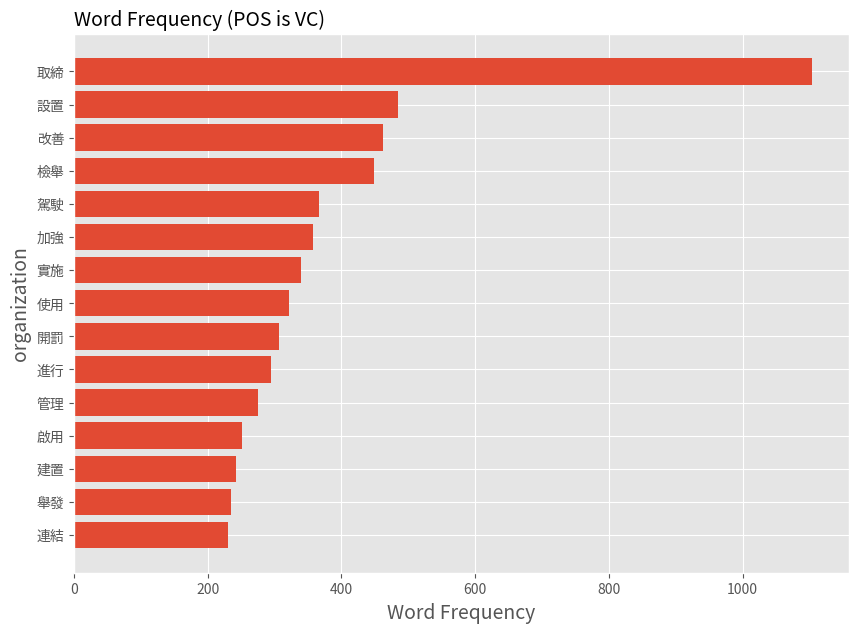

In [ ]:
word = verb_count['word']
count = verb_count['count']

fig, ax = plt.subplots(figsize =(10, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (POS is VC)',loc ='left', size = 14)
ax.set_ylabel('organization', size = 14)
ax.set_xlabel('Word Frequency', size = 14)
fig.show()

## 4.4 SnowNLP 情緒分析

In [ ]:
from snownlp import SnowNLP

In [ ]:
sentiment_date = pd.merge(
    sentence_table,
    df[['system_id', 'artDate']],
    on='system_id',
    how='left'
).dropna()

print(f"總共合併 {len(sentiment_date)} 筆句子")
sentiment_date.head(3)

總共合併 37494 筆句子


,system_id,sentence,artDate
0,1,北宜彎道死亡人數飆新高,2018-05-27
1,1,騎士自摔亡今年已死,2018-05-27
2,1,記者陳薏云新北報導,2018-05-27


### 計算句子情緒分數

In [ ]:

def get_sentiment(text):
    try:
        if not text or len(str(text).strip()) < 3:
            return None
        return round(SnowNLP(str(text)).sentiments, 4)
    except:
        return None

print("計算情緒分數")
sentiment_date['sentiment'] = sentiment_date['sentence'].apply(get_sentiment)
sentiment_date = sentiment_date.dropna(subset=['sentiment'])

print(f"完成句子數：{len(sentiment_date)}")
print(f"平均情緒分數：{sentiment_date['sentiment'].mean():.4f}")
sentiment_date.head(5)

計算情緒分數
完成句子數：35480
平均情緒分數：0.3950


,system_id,sentence,artDate,sentiment
0,1,北宜彎道死亡人數飆新高,2018-05-27,0.7354
1,1,騎士自摔亡今年已死,2018-05-27,0.2451
2,1,記者陳薏云新北報導,2018-05-27,0.9712
3,1,北宜公路是知名危險山路，前年新北段死亡人去年升至人,2018-05-27,0.9998
4,1,，大都是機車騎士，今年更多，包括昨天又有名騎士自摔後被大貨車輾斃，這個多月,2018-05-27,0.1552


### 正負面情緒統計圖

情緒分佈：
sentiment_label
負面    19669
正面    10863
中性     4948
Name: count, dtype: int64


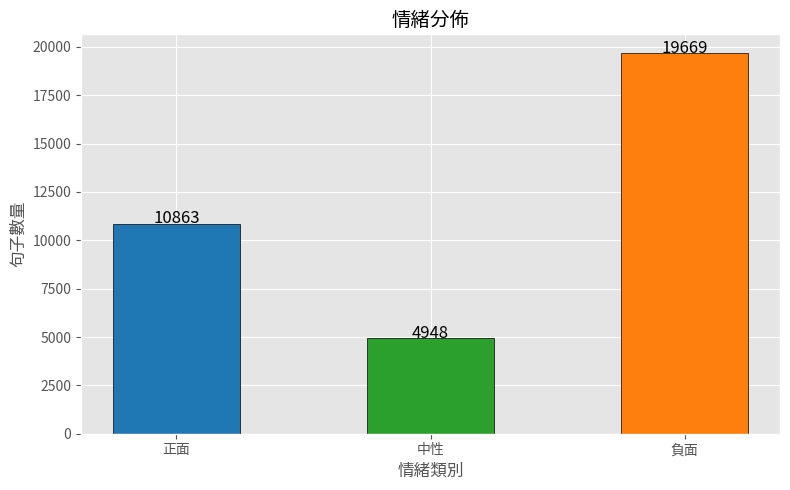

In [ ]:
def classify(score):
    if score >= 0.6:   return '正面'
    elif score <= 0.4: return '負面'
    else:              return '中性'

sentiment_date['sentiment_label'] = sentiment_date['sentiment'].apply(classify)

label_counts = sentiment_date['sentiment_label'].value_counts()
print("情緒分佈：")
print(label_counts)

# 長條圖 藍色=正面、綠色=中性、橘色=負面
COLOR_MAP = {
    '正面': '#1f77b4',
    '中性': '#2ca02c',
    '負面': '#ff7f0e'
}
ordered = ['正面', '中性', '負面']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ordered,
    [label_counts.get(l, 0) for l in ordered],
    color=[COLOR_MAP[l] for l in ordered],
    edgecolor='black', width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            str(int(bar.get_height())),
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('情緒分佈', fontsize=14)
ax.set_xlabel('情緒類別')
ax.set_ylabel('句子數量')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

### 歷年正負情緒文章趨勢

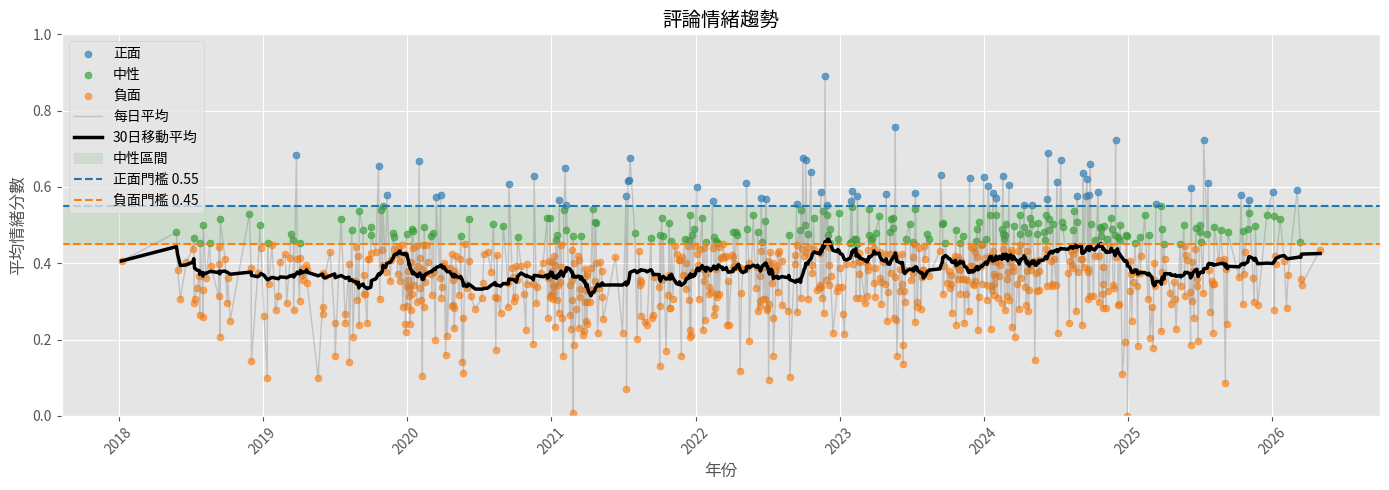

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 統一繪圖顏色：藍色=正面、綠色=中性、橘色=負面
COLOR_MAP = {
    '正面': '#1f77b4',
    '中性': '#2ca02c',
    '負面': '#ff7f0e'
}

# 日期處理
sentiment_date['artDate'] = pd.to_datetime(sentiment_date['artDate'])
sentiment_date['date_only'] = sentiment_date['artDate'].dt.date

# 每日平均情緒分數
daily = (
    sentiment_date
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

daily['date_only'] = pd.to_datetime(daily['date_only'])

# 設定正中負門檻
POS_TH = 0.55
NEG_TH = 0.45

def label_daily_sentiment(x):
    if x >= POS_TH:
        return '正面'
    elif x <= NEG_TH:
        return '負面'
    else:
        return '中性'

daily['sentiment_label'] = daily['sentiment'].apply(label_daily_sentiment)

# 30日移動平均，讓趨勢更清楚
daily['rolling_sentiment'] = daily['sentiment'].rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))

# 畫每日點：依情緒分類給顏色
for label in ['正面', '中性', '負面']:
    temp = daily[daily['sentiment_label'] == label]
    ax.scatter(
        temp['date_only'],
        temp['sentiment'],
        color=COLOR_MAP[label],
        s=25,
        alpha=0.65,
        label=label
    )

# 畫原始每日平均線
ax.plot(
    daily['date_only'],
    daily['sentiment'],
    color='gray',
    linewidth=1,
    alpha=0.35,
    label='每日平均'
)

# 畫30日趨勢線
ax.plot(
    daily['date_only'],
    daily['rolling_sentiment'],
    color='black',
    linewidth=2.5,
    label='30日移動平均'
)

# 中性區間
ax.axhspan(
    NEG_TH,
    POS_TH,
    color=COLOR_MAP['中性'],
    alpha=0.12,
    label='中性區間'
)

# 正負門檻線
ax.axhline(POS_TH, color=COLOR_MAP['正面'], linestyle='--', linewidth=1.5, label='正面門檻 0.55')
ax.axhline(NEG_TH, color=COLOR_MAP['負面'], linestyle='--', linewidth=1.5, label='負面門檻 0.45')

ax.set_title('評論情緒趨勢', fontsize=14)
ax.set_xlabel('年份')
ax.set_ylabel('平均情緒分數')
ax.set_ylim(0, 1)

plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('sentiment_trend.png', dpi=150)
plt.show()

### 負面文章文字雲

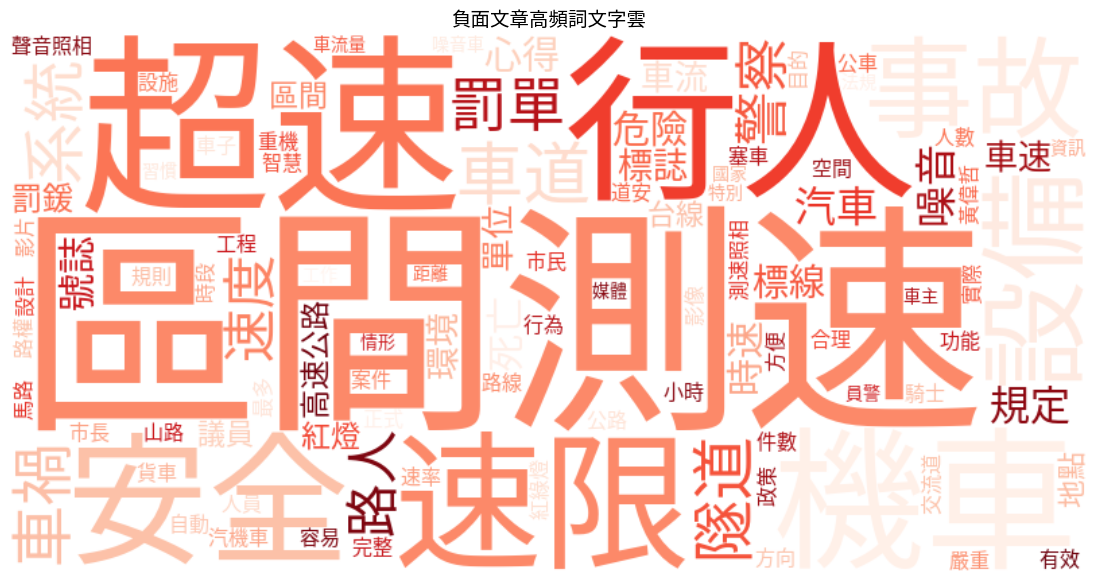

In [ ]:
# 主題背景詞：研究主題本身必然出現，文字雲排除
topic_stopwords = {
    '科技執法',
    '科技',
    '執法',
    '交通',
    '路段',
    '道路',
    '車輛',
    '駕駛人',
    '駕駛',
    '違規'
}

stop_words_home = set(stopwords) | topic_stopwords
exclude_pattern = '|'.join(topic_stopwords)


# 取出負面句子對應的 system_id
neg_ids = sentiment_date[
    sentiment_date['sentiment_label'] == '負面'
]['system_id'].unique()

for label, ids, color, fname in [
    ('負面', neg_ids, 'Reds', 'wordcloud_negative.png')
]:

    pos_table['word'] = pos_table['word'].astype(str).str.strip()

    pos_words = pos_table[
        (pos_table['system_id'].isin(ids)) &
        (pos_table['pos'].isin(['Na', 'Nb', 'VH'])) &
        (~pos_table['word'].isin(stop_words_home)) &
        (~pos_table['word'].str.contains(exclude_pattern, na=False)) &
        (pos_table['word'].str.len() >= 2)
    ]

    if pos_words.empty:
        print(f'{label} 文章詞彙為空，跳過')
        continue

    wc = WordCloud(
        font_path='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        stopwords=stop_words_home,
        collocations=False,
        width=800,
        height=400,
        max_words=100,
        background_color='white',
        colormap=color
    )

    wc.generate(' '.join(pos_words['word']))

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{label}文章高頻詞文字雲', fontsize=14)
    plt.savefig(fname, dpi=150)
    plt.show()

In [ ]:
# 將負面詞彙高頻文字定義負面原因主題詞籃
concern_rules = {
    '開罰斂財質疑': {
        'strong': [
            '搶錢', '斂財', '撈錢', '罰單經濟',
            '衝業績', '業績壓力', '開罰機器', '國庫'
        ],
        'topic': ['罰單', '開罰', '罰款', '裁罰'],
        'issue': ['太多', '狂開', '只會', '拼業績', '賺錢', '收入']
    },

    '測速限速爭議': {
        'strong': [
            '區間測速', '測速照相', '速限過低',
            '限速不合理', '速限不一致', '速限忽高忽低',
            '超速陷阱', '測速陷阱'
        ],
        'topic': ['測速', '限速', '速限', '超速', '時速'],
        'issue': ['不合理', '太低', '忽高忽低', '不一致', '突然', '陷阱', '容易被罰']
    },

    '設置地點爭議': {
        'strong': [
            '設置不當', '地點不合理', '標示不清',
            '標誌不明顯', '標線不清', '告示不明',
            '陷阱路段', '沒有告示'
        ],
        'topic': ['路口', '路段', '地點', '標誌', '標線', '號誌', '告示', '下坡', '匝道', '彎道'],
        'issue': ['不清', '不明', '不明顯', '不合理', '看不到', '太小', '突然', '來不及', '陷阱']
    },

    '執法公平疑慮': {
        'strong': [
            '選擇性執法', '執法不公', '雙重標準',
            '標準不一', '只抓機車', '只抓小老百姓',
            '檢舉魔人', '亂檢舉', '裁罰不公'
        ],
        'topic': ['取締', '執法', '檢舉', '裁罰', '警察', '交通局'],
        'issue': ['不公', '不公平', '雙標', '標準不一', '選擇性', '亂', '只抓']
    },

    '設備誤判問題': {
        'strong': [
            '誤判', '誤拍', '拍錯', '亂拍',
            '辨識錯誤', '車牌辨識錯誤',
            '設備故障', '鏡頭故障', '系統錯誤',
            '烏龍罰單'
        ],
        'topic': ['設備', '鏡頭', '相機', '系統', '辨識', '拍照', '監視器'],
        'issue': ['故障', '錯誤', '誤判', '誤拍', '拍錯', '亂拍', '申訴']
    },

    '安全效果存疑': {
        'strong': [
            '沒有效果', '成效不彰', '治標不治本',
            '沒有改善', '事故沒有減少',
            '只是開罰', '不是真安全', '反而危險'
        ],
        'topic': ['安全', '事故', '車禍', '改善', '防制'],
        'issue': ['沒用', '無效', '沒有改善', '未改善', '沒減少', '反而', '治標不治本']
    }
}

In [ ]:
# 依據 strong 或 topic + issue 判斷句子所屬的不滿原因
def classify_concern(text):
    text = str(text)
    matched = []

    for category, rule in concern_rules.items():
        strong_hit = any(k in text for k in rule['strong'])

        combo_hit = (
            any(t in text for t in rule['topic']) and
            any(i in text for i in rule['issue'])
        )

        if strong_hit or combo_hit:
            matched.append(category)

    return matched if matched else ['未分類']

In [ ]:
# 取出負面文章對應的句子
neg_sentence_df = sentence_table[
    sentence_table['system_id'].isin(neg_ids)
].copy()

# 分類
neg_sentence_df['concern_category'] = neg_sentence_df['sentence'].apply(classify_concern)

# 一句可能符合多個類別，所以 explode 展開
concern_long = neg_sentence_df.explode('concern_category')

# 統計各類別出現句子數
result = (
    concern_long['concern_category']
    .value_counts()
    .reindex(list(concern_rules.keys()), fill_value=0)
)

result

,count
concern_category,
開罰斂財質疑,134
測速限速爭議,1721
設置地點爭議,44
執法公平疑慮,38
設備誤判問題,36
安全效果存疑,36


### 負面文章種類區分

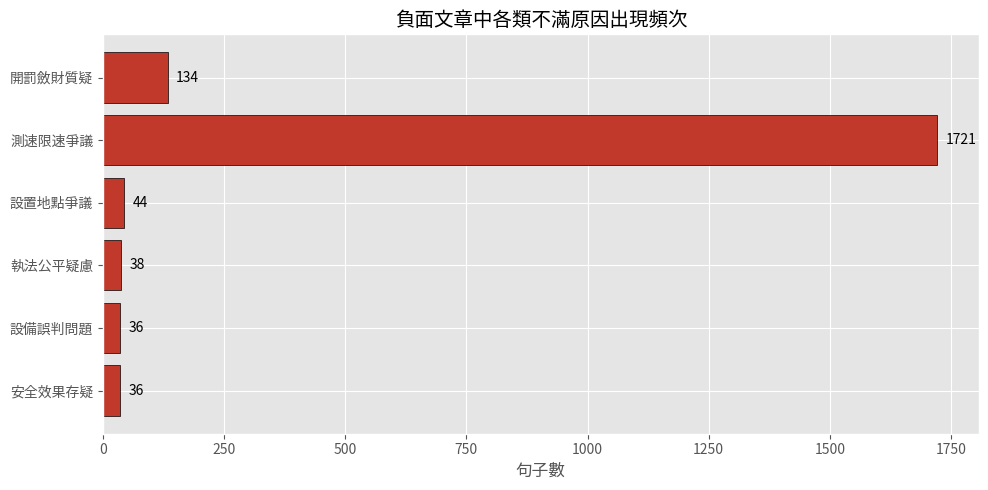

In [ ]:
import matplotlib.pyplot as plt

categories = result.index.tolist()
counts = result.values.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(categories, counts, color='#C0392B', edgecolor='black')

ax.invert_yaxis()
ax.set_title('負面文章中各類不滿原因出現頻次', fontsize=14)
ax.set_xlabel('句子數')

for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_width() + max(counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(cnt),
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# 查看各類別範例句
for cat in concern_rules.keys():
    print('\n====', cat, '====')
    display(
        concern_long[concern_long['concern_category'] == cat][
            ['system_id', 'sentence']
        ].head(15)
    )


==== 開罰斂財質疑 ====


,system_id,sentence
432,14,若是噪音超過標準值將會寄出罰單，而這套系統在目前的設置下，只會針對影像範圍內噪
840,32,你當然也可以覺得政府搶錢，我愛騎快開快很安全，
917,35,啊拜託也不要在虛線擺相機，為了斂財擺的相機對交通安全點也沒有幫助
1910,68,為了搶錢
2577,94,所以幹你娘搶錢用的智障區間測速什麼時候才會廢止阿
3632,117,數數看短短秒，國庫進帳多少錢
3663,119,社團堆人開始靠北政府開始搶錢，笑死，禮讓行人這最基本該做的到了基隆好像變得說政
3773,122,搶錢啦
4204,136,他說，科技執法要找對重點，不能為裝而裝，不然駕駛者會認為政府搶錢，徒生
5015,153,▼站在科技執法斑馬線上聊天，是要幫警察衝業績嗎



==== 測速限速爭議 ====


,system_id,sentence
121,3,還有就是目前疑似有試辦區間測速，首席有提醒，導航王則是沒反應
191,6,區間測速區段
192,6,個人非常贊同區間測速，不過剛剛看到新聞才知道
197,6,後面也順便提了自強隧道年底也加入區間測速的行列
204,7,警方有鑑於重大車禍事故頻傳，加上萬里隧道實施區間平均速率執法後，成效顯著，因此規劃北宜公路公...
208,7,另外，在月日至日平日期間天只有輛違規僅占，而清明連假天月日至日違規車輛有輛占，平均每日輛，假...
210,7,而針對近來有少數機車駕駛人在測速路段終點前停等，規避超速的情形，新北警強調，此作法雖無明確的...
274,8,騎太快等下區間測速
314,9,想問大家北宜公路區間測速
460,15,北市自強隧道自月日起正式實施區間測速及跨越雙白線科技執法‼



==== 設置地點爭議 ====


...

,system_id,sentence
2256,76,而不是養工處交通局交通部工作亂做
3941,125,印象怎麼以前有人這樣檢舉結果被警察打槍的，突然覺得我們的交通法規真的是個笑話，各種雙標
4047,129,只針對機車摩托車執法是非常雙重標準的
4094,130,系統只抓機車
4097,130,人家只是開發廠商當然不負責定裁罰標準，亂搞的還是彰化縣政府跟警察局
7939,248,錄影取締亂丟垃圾南市環保局個月開罰百餘件
8087,250,為了整頓這種亂像，所以導入科技執法，就是原文提到的狀況，這大概是近五年的事
8096,250,但是三線城市如鄭州，還是樣亂，但聽說也將會導入科技執法
9321,301,住在台灣就只能接受這切，人心是肉做的，要改變交通亂象，除了靠科技執法自動開單，別無他法了
10913,369,而不是讓違規可以更加合理化，然後交通更加混亂，甚至還來檢討檢舉人，冠上檢舉達人這樣的負面稱號...



==== 設備誤判問題 ====


,system_id,sentence
388,13,不知道會不會有誤判喇叭聲
1058,40,申訴曠日廢時必定造成民眾不便，建議科技設備拍到後通知人工檢驗
1060,40,人工檢驗噪音超標當然開罰，但若證明是科技設備誤判，需有合理補償措施
1061,40,畢竟民眾是花費自己的時間來受檢，且是因為機器誤判導致
1062,40,倘若政府對這套系統深具信心，那拿收來的罰緩補償誤判的民眾沒問題吧
4099,130,我覺得比起區間測速，要擋下這個系統的機率可能更低，而且申訴成功機率幾乎成為
5135,156,感謝總代理願意讓我亂拍公司內部
10417,346,縣警察局交通隊派員檢視，發現系統攝影機對時韌體異常，造成該筆資料時間錯誤，致使
10423,346,卻發現區間測速舉發的正確性，進而查出此區間測速系統故障的烏龍事牛
10435,346,使用，並送交第三方公證單位驗證，並從今天日進行回溯清查設備故障問題是從自



==== 安全效果存疑 ====


,system_id,sentence
826,32,當然，我認為這是個治標不治本的措施，
2308,80,駛不但無法注意路況，反而造成了行車安全的危險，政府有預算應該花在道路規劃與維護
3079,111,上山的話反而只有剛進偵測區的直線和地藏王廟九鳳宮可以停的比較安全點
3593,116,右根本也不是為了安全，反而造成更多危險
3917,123,為何前面才說區間沒用，後面又說區間可以降事故
3991,126,個月改善，遲未改善，嚴重可註銷牌照
6053,172,這篇文本來的宗旨就不是要探討道路安全以及怎麼改善，而是對取締最多的項目反而不是
7737,242,林口這個南下交流道科技執法執行後似乎沒有改善，剛好爬坡路段尾巴，很多投機的
10304,340,如果像國道那樣佛系取締大概成效不彰
10582,355,趁駕駛還沒疲累讓其更快駛離高速公路會不會反而更可以減少事故發生


## 5.1詞彙分析:Bigram

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import jieba
import jieba.analyse
import math
from nltk import ngrams, FreqDist
from collections import Counter, namedtuple

import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

資料匯入

In [ ]:
car_df = clear_df.copy()
car_df.head(3)

,system_id,artUrl,artTitle,artDate,artContent,sentence
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...
1,2,https://www.ptt.cc/bbs/biker/M.1538017079.A.C4...,[新聞]重機上國道年度檢核出爐 保持安全車距觀,2018-09-27,https://tw.news.appledaily.com/life/realtime/2...,保持安全車距觀念仍不足。107/09/27。550CC以上紅牌大型重機爭取上國道各界爭議，...
2,3,https://www.ptt.cc/bbs/biker/M.1538495370.A.4F...,Re:[新車]GSX-R150,2018-10-02,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。\n你的定位是平日通勤、假日跑山，那你的...,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。你的定位是平日通勤、假日跑山，那你的通勤...


In [ ]:
# 利用nltk的ngrams()
# Bigram
bigram  = ngrams(car_df, 2)
list(bigram)

[('system_id', 'artUrl'),
 ('artUrl', 'artTitle'),
 ('artTitle', 'artDate'),
 ('artDate', 'artContent'),
 ('artContent', 'sentence')]

In [ ]:
import re

# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字、字元數小於等於1、以及含有數字的詞彙
    seg_list = [
        w for w in seg_list
        if w not in stopwords
        and len(w) > 1
        and not re.search(r'\d', w)
    ]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [ ]:
car_bigram = car_df.head(3)

car_bigram["word"] = car_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
car_bigram = car_bigram.explode('word')

car_bigram.head(5)

,system_id,artUrl,artTitle,artDate,artContent,sentence,word
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,彎道 死亡
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,死亡 人數
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,人數 新高
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,新高 騎士
0,1,https://www.ptt.cc/bbs/biker/M.1527402276.A.4D...,[新聞]北宜彎道死亡人數「飆」新高,2018-05-27,北宜彎道 死亡人數「飆」新高\n2018-05-27\n\n騎士自摔亡 今年已7死\n\n〔...,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,騎士 摔亡


### bigram出現頻率

In [ ]:
car_bigram['word'] = car_bigram['word'].astype(str)

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
car_bigram = FreqDist(car_bigram['word'].apply(lambda x: tuple(x.split(' '))))
car_bigram.most_common(5)

[(('檢核', '小組'), 6),
 (('機車', '騎士'), 3),
 (('騎乘', '姿勢'), 3),
 (('死亡', '人數'), 2),
 (('貨車', '輾斃'), 2)]

In [ ]:
# 建立bigram和count的dictionary
# 這裡取最多的前50項
d = {k:v for k,v in car_bigram.most_common(50)}

### 5.2 共詞網絡圖

In [ ]:
import pandas as pd
from nltk.probability import FreqDist

# 建立 bigram 和 count 的 dictionary
# 取出前 80 組 bigram
top_n_edges = 80
min_edge_weight = 1

# Check if car_bigram is a DataFrame and convert it to FreqDist if needed
# This assumes car_bigram is a DataFrame with a 'word' column containing bigram strings
# if it has not been converted to FreqDist in a prior step.
if isinstance(car_bigram, pd.DataFrame) and 'word' in car_bigram.columns:
    car_bigram_freqdist = FreqDist(car_bigram['word'].apply(lambda x: tuple(x.split(' '))))
else:
    # If it's already a FreqDist or another type, use it directly
    car_bigram_freqdist = car_bigram

d = {
    k: v for k, v in car_bigram_freqdist.most_common(top_n_edges)
    if v >= min_edge_weight
}

print("bigram 數量：", len(d))

bigram 數量： 80


In [ ]:
# Create network plot
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# 建立邊線
# k[0]、k[1] 是兩個詞，v 是共現次數
for k, v in d.items():
    G.add_edge(k[0], k[1], weight=v)

print("節點數：", G.number_of_nodes())
print("邊線數：", G.number_of_edges())

# 取得 edge 權重
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# 將線條粗細標準化，避免線太淡看不到
max_weight = max(edge_weights)

weights = [
    G[u][v]['weight'] / max_weight * 5
    for u, v in G.edges()
]

節點數： 86
邊線數： 78


從科技執法相關文章共詞網絡圖可以看出，文本主要圍繞交通安全、機車與大型重機、駕駛行為及違規管理等議題。其中，「科技執法」、「行車安全」、「保持」、「檢核」等詞彙的連結，顯示科技執法常被放在交通安全管理脈絡下討論；而「大型重機」、「機車」、「騎士」、「彎道」、「山路」等詞彙則反映出機車與重機騎乘安全是重要關注面向。此外，「駕駛行為」、「觀念」、「違規」、「取締」等詞彙的出現，表示文章也強調用路人行為改善與違規管理。整體而言，該網絡圖呈現出科技執法與交通安全、騎乘風險、駕駛行為及日常用路情境之間的關聯。

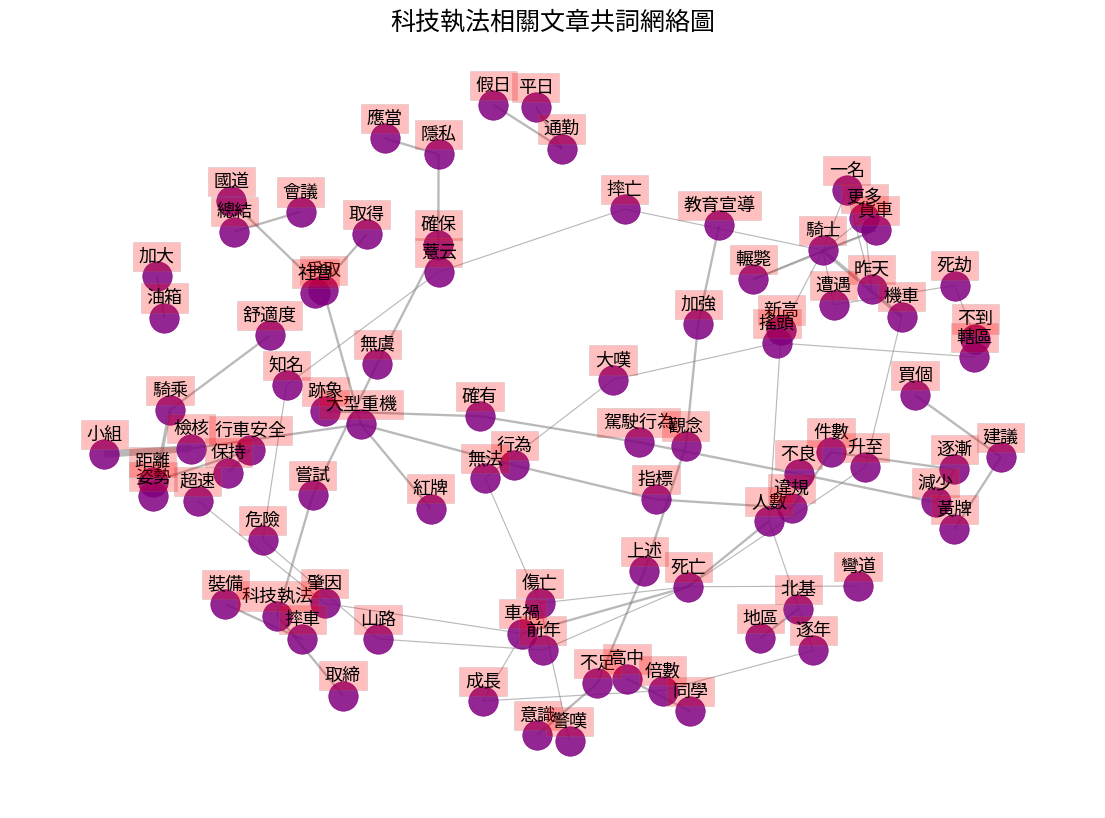

In [ ]:
# 畫共詞網絡圖
fig, ax = plt.subplots(figsize=(14, 10))

# spring_layout 會讓有關聯的詞靠近
pos = nx.spring_layout(
    G,
    k=0.8,
    iterations=100,
    seed=777
)

# 畫線
nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    edge_color='gray',
    alpha=0.55,
    ax=ax
)

# 畫節點
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='purple',
    node_size=450,
    alpha=0.85,
    ax=ax
)

# 畫標籤
for key, value in pos.items():
    x, y = value[0], value[1]

    ax.text(
        x,
        y + 0.045,
        s=key,
        bbox=dict(
            facecolor='red',
            alpha=0.25,
            edgecolor='gray'
        ),
        horizontalalignment='center',
        fontsize=13
    )

plt.title('科技執法相關文章共詞網絡圖', fontsize=18)
plt.axis('off')
plt.show()

In [ ]:
import re

def getToken(row):
    seg_list = jieba.lcut(row)

    seg_list = [
        w for w in seg_list
        if w not in stopwords
        and len(w) > 1
        and re.fullmatch(r'[\u4e00-\u9fff]+', w)
    ]

    return seg_list

In [ ]:
# 保留需要的欄位
car_df = car_df.loc[:,["system_id", "sentence"]]

# 改成使用空格連接斷完的詞
car_df['word'] = car_df.sentence.apply(getToken).map(' '.join)

car_df.head()

,system_id,sentence,word
0,1,北宜彎道 死亡人數「飆」新高2018-05-27。騎士自摔亡 今年已7死。〔記者陳薏云／新北...,彎道 死亡 人數 新高 騎士 摔亡 薏云 知名 危險 山路 前年 死亡 升至 機車 騎士 更...
1,2,保持安全車距觀念仍不足。107/09/27。550CC以上紅牌大型重機爭取上國道各界爭議，...,保持 安全 車距 觀念 不足 紅牌 大型重機 爭取 國道 各界 爭議 交通部 委託 外部 專...
2,3,我目前騎小阿魯，也有租過R15V3，簡單和你說一下。你的定位是平日通勤、假日跑山，那你的通勤...,騎小 租過 定位 平日 通勤 假日 跑山 那你 通勤 平時 需要 騎多少 縣市 上班 那種 ...
3,4,原文網址 要我上去 真的不太想。,不太想
4,5,新聞來源 自由時報 區間速率年底上路2019-03-26 21:25。［記者陳賢義／台東報導...,區間速率 年底 上路 賢義 防範 南迴 拓寬 工程 安朔 草埔 隧道 新台 預定 年底 完工...


In [ ]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前300的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 300)
X = vectorizer.fit_transform(car_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一台,一堆,一次,一段,一直,一路,一點,上路,下降,不依,...,駕駛,駕駛人,騎士,騎車,高速,高速公路,高鐵,高雄市,黃偉哲,龍崎
0,0,0,0,0,0,0,0,0,0,0,...,0,0,8,3,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,2,1,1,0,0,1,0,0,0,0
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
1429,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1431,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [ ]:
# 計算詞之間的相關係數
corr_matrix = np.corrcoef(DTM_df.T)

# 轉成dataframe
Cor_df = pd.DataFrame(corr_matrix, index = DTM_df.columns, columns = DTM_df.columns)

Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace = True, drop = True)

Cor_df

,word1,一台,一堆,一次,一段,一直,一路,一點,上路,下降,...,駕駛,駕駛人,騎士,騎車,高速,高速公路,高鐵,高雄市,黃偉哲,龍崎
0,一台,1.000000,0.009443,0.063707,0.019094,0.154498,0.043518,0.122871,-0.032429,-0.027893,...,0.030678,-0.026325,-0.005518,0.132365,0.118725,0.070849,-0.017505,0.025075,-0.015171,-0.019333
1,一堆,0.009443,1.000000,0.073362,0.013778,0.179555,-0.002111,0.080073,0.021251,0.009836,...,0.093487,0.051342,0.004022,0.088746,0.027043,0.081368,-0.001751,0.017240,-0.025026,-0.034653
2,一次,0.063707,0.073362,1.000000,0.064363,0.173983,0.053924,0.207236,0.012850,0.017812,...,0.035290,0.030456,0.015442,0.041560,0.086800,0.048693,-0.009298,0.001010,-0.018691,-0.005492
3,一段,0.019094,0.013778,0.064363,1.000000,0.117870,0.031295,0.053000,0.034402,-0.009624,...,0.007376,-0.001733,0.018039,0.069532,0.051959,0.032619,-0.018620,-0.011128,-0.016017,-0.020411
4,一直,0.154498,0.179555,0.173983,0.117870,1.000000,0.039422,0.115578,-0.034898,0.009372,...,0.045181,0.009390,0.017504,0.125812,0.137103,0.145702,-0.017783,0.028277,-0.016369,-0.010567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,高速公路,0.070849,0.081368,0.048693,0.032619,0.145702,0.026023,0.055379,0.019421,0.007971,...,0.197737,0.123795,0.001500,-0.020098,0.224373,1.000000,-0.027964,-0.021559,-0.020544,-0.026180
296,高鐵,-0.017505,-0.001751,-0.009298,-0.018620,-0.017783,0.085482,-0.008141,-0.003916,0.062364,...,0.024253,0.021936,0.006924,-0.023704,-0.000133,-0.027964,1.000000,-0.003287,0.142836,-0.013694
297,高雄市,0.025075,0.017240,0.001010,-0.011128,0.028277,0.026369,0.007175,-0.023590,0.022994,...,-0.016111,0.001692,0.037980,0.002946,-0.018639,-0.021559,-0.003287,1.000000,0.008194,0.000627
298,黃偉哲,-0.015171,-0.025026,-0.018691,-0.016017,-0.016369,-0.014323,-0.018007,-0.016851,0.021753,...,0.034467,0.043822,0.001553,-0.016013,-0.014767,-0.020544,0.142836,0.008194,1.000000,0.004713


In [ ]:
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

word_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
56011,行政,管理,0.930999
63486,管理,行政,0.930999
63432,政策,行政,0.870442
39811,行政,政策,0.870442
55932,政策,管理,0.835348
39786,管理,政策,0.835348
62851,標誌,號誌,0.826046
45509,號誌,標誌,0.826046
3211,行政,中央,0.822306
63310,中央,行政,0.822306


In [ ]:
rider_sum = word_cor_df[(word_cor_df["word1"] == "騎士")].sort_values(by = ['cor'], ascending = False).head(10)
walk_sum = word_cor_df[(word_cor_df["word1"] == "行人")].sort_values(by = ['cor'], ascending = False).head(10)

### 5.3 詞彙相關性

從詞彙關聯可以看出，「騎士」類別中關聯程度較高的詞彙包含「機車」、「重機」、「彎道」、「危險」、「死亡」等，顯示該類別文本多與機車騎乘、事故發生及道路風險有關。而「行人」類別中，「號誌」、「通行」、「路口」、「處罰」、「闖紅燈」等詞彙具有較高關聯，表示行人相關文章主要聚焦於路口通行規範、交通號誌遵守與違規處罰。整體而言，騎士議題偏向事故與騎乘安全，行人議題則偏向交通規則與路口安全管理。

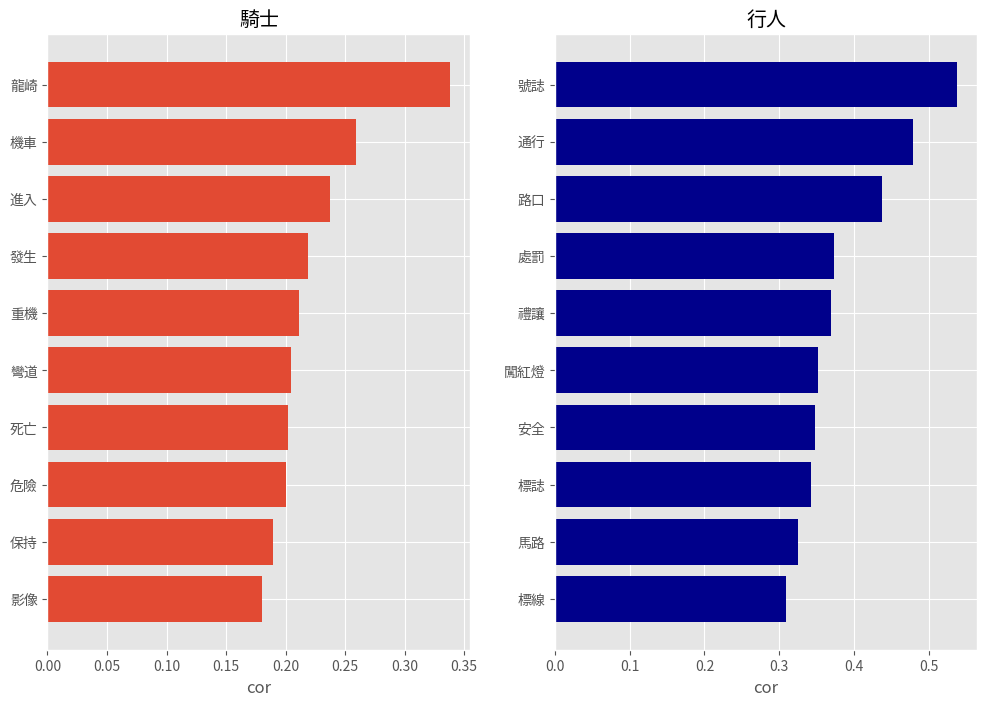

In [ ]:
plt.figure(figsize=(12,8))   # 顯示圖框架大小 (寬,高)
plt.style.use("ggplot")     # 使用ggplot主題樣式

plt.subplot(121)
plt.title('騎士')
plt.xlabel('cor')
plt.barh(rider_sum['word2'],rider_sum['cor'])
plt.gca().invert_yaxis()

plt.subplot(122)
plt.title('行人')
plt.xlabel('cor')
plt.barh(walk_sum['word2'],walk_sum['cor'],color="darkblue")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 透過DTM找出詞頻前60高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})

most_freq_word = most_freq_df['word'].tolist()

In [ ]:
# 保留存在詞頻前60高之詞彙的組合
filtered_df = word_cor_df[(word_cor_df['word1'].isin(most_freq_word)) & (word_cor_df['word2'].isin(most_freq_word))]

# 篩選出相關係數大於0.3的組合
filtered_df = filtered_df[filtered_df['cor'] > 0.3]
filtered_df.reset_index(inplace=True, drop=True)
filtered_df

,word1,word2,cor
0,交通,事故,0.318298
1,交通事故,事故,0.486868
2,執法,事故,0.393754
3,安全,事故,0.312661
4,死亡,事故,0.448802
...,...,...,...
155,路口,闖紅燈,0.583269
156,機車,駕駛,0.309987
157,汽車,駕駛,0.374838
158,規定,駕駛人,0.409519


In [ ]:
# Create network plot
g = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 取得edge權重
weights = [w[2]['weight']*5 for w in  g.edges(data=True)]

### 5.4 詞彙關係圖

從詞彙共現網絡圖可以看出，文本主要圍繞交通安全與交通管理議題展開。其中，「科技執法」、「違規」、「取締」、「設備」與「系統」位於網絡中心，顯示科技執法是文本中的核心議題，並常與違規取締、超速偵測及路段管理相關。另一方面，「交通事故」、「事故」、「死亡」、「安全」等詞彙形成事故風險相關群聚，表示文章也關注交通事故發生及其造成的安全問題。此外，「行人」、「路口」、「標線」等詞反映出行人通行與路口安全議題，而「市府」、「環保局」、「噪音」、「管理」則呈現政府對車輛與噪音問題的管理面向。整體而言，此圖顯示文本討論重點集中在科技執法、交通違規、事故防制、行人安全與政府治理等面向。

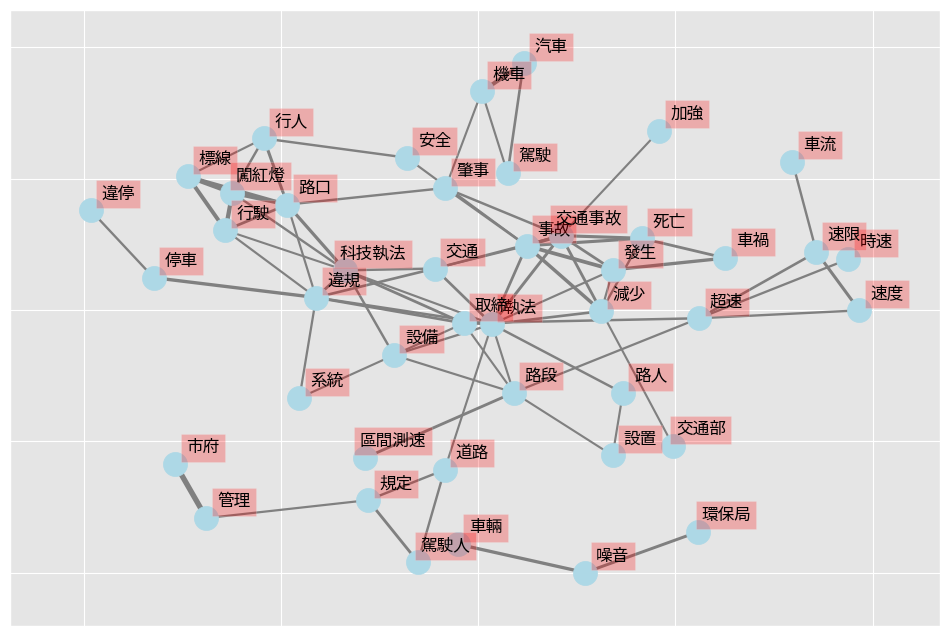

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g, k=0.3)

# networks
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.show()

## 7.1主題模型

### 安裝套件

In [ ]:
# 如果還沒安裝，先執行這行；已安裝可註解掉
!pip install bertopic sentence-transformers hdbscan umap-learn -q

import os
import re
import jieba
import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer


### 資料匯入及清洗

In [ ]:
# 文章類別
city_list = ['Hsinchu', 'Kaohsiung', 'TaichungBus', 'Tainan', 'car', 'biker']

# 篩選文章
city_data = udn[udn['artCatagory'].isin(city_list)].copy()

# 移除空文章
city_data = city_data.dropna(subset=['sentence'])

# 確認資料量
print("各文章數量：")
print(city_data['artCatagory'].value_counts())
print("文章總數：", len(city_data))

# 文章內容
docs_zh = city_data['sentence'].astype(str).tolist()


# 載入檔案停用詞
with open('stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = [line.strip() for line in f if line.strip()]

# 手動新增停用詞
stopwords_manual = [
    "原文", "連結", "報導", "現在", "目前", "一部", "這種", "感覺", "表示", "時間",
    "內容", "文章", "覺得", "真的", "有點", "完全", "相當", "不錯", "部分", "表現",
    "提供", "台灣", "台北", "這樣", "時候", "直接", "正常", "狀況", "基本", "重要",
    "重點", "情況", "可能", "簡單", "明顯", "數據", "平均", "之後", "還是", "就是",
    "因為", "所以", "但是", "如果", "已經", "沒有", "應該", "修凱", "公里", "使用"
]

# 合併檔案停用詞與手動停用詞
stopwords = list(set(stopwords + stopwords_manual))

def tokenize_zh(text):
    words = jieba.lcut(str(text))

    words = [
        w for w in words
        if w not in stopwords
        and len(w) > 1
        and not re.search(r'[A-Za-z0-9]', w)
        and re.fullmatch(r'[\u4e00-\u9fff]+', w)
    ]

    return words

各文章數量：
artCatagory
car          796
Tainan       213
biker        166
Kaohsiung     96
Hsinchu       60
Name: count, dtype: int64
文章總數： 1331


### 載入embedding model

In [ ]:
# 中文 embedding model
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 轉換文章 embedding
embeddings = embedding_model.encode(
    docs_zh,
    show_progress_bar=True
)

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
# 文章類別
category_list = ['Hsinchu', 'Kaohsiung', 'TaichungBus', 'Tainan', 'car', 'biker']

# 篩選文章
# 如果 udn 已經是科技執法相關文章，這裡只需要篩選類別即可
city_data = udn[udn['artCatagory'].isin(category_list)].copy()

# 移除空文章
city_data = city_data.dropna(subset=['sentence'])
city_data = city_data[city_data['sentence'].astype(str).str.strip() != '']

# 確認資料量
print("各文章數量：")
print(city_data['artCatagory'].value_counts())
print("文章總數：", len(city_data))

# 文章內容
docs_zh = city_data['sentence'].astype(str).tolist()
n_docs = len(docs_zh)


# 載入檔案停用詞
with open('stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = [line.strip() for line in f if line.strip()]

# 手動新增停用詞
stopwords_manual = [
    "原文", "連結", "報導", "現在", "目前", "一部", "這種", "感覺", "表示", "時間",
    "內容", "文章", "覺得", "真的", "有點", "完全", "相當", "不錯", "部分", "表現",
    "提供", "台灣", "台北", "這樣", "時候", "直接", "正常", "狀況", "基本", "重要",
    "重點", "情況", "可能", "簡單", "明顯", "數據", "平均", "之後", "還是", "就是",
    "因為", "所以", "但是", "如果", "已經", "沒有", "應該", "修凱", "公里", "使用"
]

# 合併檔案停用詞與手動停用詞
stopwords = list(set(stopwords + stopwords_manual))


# 中文斷詞 function：過濾停用字、英文、數字、標點
def tokenize_zh(text):
    words = jieba.lcut(str(text))

    words = [
        w for w in words
        if w not in stopwords
        and len(w) > 1
        and not re.search(r'[A-Za-z0-9]', w)
        and re.fullmatch(r'[\u4e00-\u9fff]+', w)
    ]

    return words


# UMAP 降維
umap_model = UMAP(
    n_neighbors=min(15, max(2, n_docs - 1)),
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=777
)

# HDBSCAN 分群
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# CountVectorizer 使用 jieba 斷詞
vectorizer_model = CountVectorizer(
    tokenizer=tokenize_zh,
    analyzer='word',
    token_pattern=None,
    min_df=2
)

# 建立 BERTopic 模型
# 這裡讓 BERTopic 自動處理 multilingual embedding
topic_model = BERTopic(
    language="multilingual",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    nr_topics="auto",
    verbose=True
)


各文章數量：
artCatagory
car          796
Tainan       213
biker        166
Kaohsiung     96
Hsinchu       60
Name: count, dtype: int64
文章總數： 1331


### 訓練 BERTopic

In [ ]:
# 訓練 BERTopic
topics, probs = topic_model.fit_transform(docs_zh)

# 將 topic 加回資料
city_data = city_data.reset_index(drop=True)
city_data['topic'] = topics

# 查看主題資訊
topic_info = topic_model.get_topic_info()
display(topic_info)

2026-06-03 14:22:22,062 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

2026-06-03 14:25:07,242 - BERTopic - Embedding - Completed ✓
2026-06-03 14:25:07,246 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 14:25:12,477 - BERTopic - Dimensionality - Completed ✓
2026-06-03 14:25:12,479 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 14:25:12,532 - BERTopic - Cluster - Completed ✓
2026-06-03 14:25:12,533 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-03 14:25:26,397 - BERTopic - Representation - Completed ✓
2026-06-03 14:25:26,398 - BERTopic - Topic reduction - Reducing number of topics
2026-06-03 14:25:26,413 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 14:25:41,030 - BERTopic - Representation - Completed ✓
2026-06-03 14:25:41,034 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_草埔_休旅車_元旦_分鐘,"[草埔, 休旅車, 元旦, 分鐘, 隧道, 時速, 新路, 萬元, 支援, 啟用]",[分享導航王即將支援就在剛剛在臉書看到導航王即將支援支援區間測速路提示智慧多路徑規劃一次提供...
1,0,1225,0_科技執法_區間測速_違規_交通,"[科技執法, 區間測速, 違規, 交通, 路口, 路段, 超速, 取締, 行人, 執法]",[新聞高市處科技執法去年舉發萬件原文連結原文內容高市處科技執法去年舉發萬件聯合報記者石秀華潘...
2,1,53,1_噪音_聲音照相_環保局_車輛,"[噪音, 聲音照相, 環保局, 車輛, 噪音車, 改裝, 稽查, 取締, 噪音車輛, 設備]",[新聞台南增聲音照相取締改裝車噪音台南增聲音照相取締改裝車噪音聯合報記者吳淑玲台南報導南市環...
3,2,35,2_這段_南迴_路線_民宿,"[這段, 南迴, 路線, 民宿, 花蓮, 一點, 油耗, 繼續, 休息, 車友]",[心得你小老婆真棒環半島圖多代誌洗安內欸強者我朋友高雄北漂仔前陣子買了一台然後在高雄的鈴駒車...
4,3,15,3_充電_原廠_引擎_價格,"[充電, 原廠, 引擎, 價格, 心得, 一台, 台車, 動力, 電車, 體驗]",[心得開箱心得上次被朋友勸敗偽之後最終我也不小心手滑買了一台月之前出廠的至於為什麼想買呢現在...


## 文章主題分布

In [ ]:
# 主題數量表
city_topic_table = pd.crosstab(
    city_data['artCatagory'],
    city_data['topic']
)

display(city_topic_table)

topic,-1,0,1,2,3
artCatagory,,,,,
Hsinchu,0,57,3,0,0
Kaohsiung,0,93,2,1,0
Tainan,0,184,27,1,1
biker,0,128,13,20,5
car,3,763,8,13,9


In [ ]:

# 主題比例表
city_topic_ratio = pd.crosstab(
    city_data['artCatagory'],
    city_data['topic'],
    normalize='index'
)

display(city_topic_ratio)

topic,-1,0,1,2,3
artCatagory,,,,,
Hsinchu,0.000000,0.950000,0.050000,0.000000,0.000000
Kaohsiung,0.000000,0.968750,0.020833,0.010417,0.000000
Tainan,0.000000,0.863850,0.126761,0.004695,0.004695
biker,0.000000,0.771084,0.078313,0.120482,0.030120
car,0.003769,0.958543,0.010050,0.016332,0.011307


## 7.2 文章主題分布圖

In [ ]:
#主題距離圖
try:
    fig = topic_model.visualize_topics()

    fig.update_layout(
        title='科技執法相關文章主題分布圖',
        title_x=0.5,
        width=900,
        height=700
    )

    fig.show()
except Exception as e:
    print("主題分布圖無法顯示：", e)


## 7.3 文章主題關鍵字

In [ ]:
# 主題關鍵字長條圖
try:
    fig_bar = topic_model.visualize_barchart(top_n_topics=10)

    fig_bar.update_layout(
        title='科技執法文章主題關鍵字',
        title_x=0.5
    )

    fig_bar.show()
except Exception as e:
    print("主題關鍵字圖無法顯示：", e)